# Análise dos resultados — Sistemas Multiagente (GSM8K)

Este notebook analisa os experimentos salvos em **`results/runs/`** (varredura
principal, *n=30* perguntas por configuração) e em **`results/backup_runs/`**
(execuções complementares mais longas, *n=200*, com modelos maiores e o
protocolo de **Debate**).

Cada execução vive em uma pasta com o padrão
`<protocolo>__min-<minion>__mas-<master>__n<k>` contendo:

| arquivo | conteúdo |
|---|---|
| `summary.json` | métricas agregadas da configuração |
| `meta.json` | metadados (dataset, modelos, nº de parâmetros, seed) |
| `raw.json` | um registro por pergunta (acerto, latência, tokens, `extra`) |
| `agent_costs.json` | custo por agente (apenas `foa_dag`) |

**Estrutura da análise**

1. Carregamento e visão geral dos experimentos
2. Panorama comparativo entre protocolos
3. **Mergulho no FoA — efeito do número de agentes `n`**
4. FoA vs FoA-DAG e a economia de custo por agente
5. Dinâmica interna do FoA (consenso e rodadas)
6. **Seção final — explorando os `backup_runs`** (modelos grandes, debate, escala)

Inspirado no estilo de `graficos_v3.ipynb`, com estética de artigo científico.

## 1. Configuração e estilo visual

Definimos uma paleta consistente e parâmetros de figura com qualidade de publicação (tipografia, *despine*, grade sutil, alta resolução).

In [1]:
%matplotlib inline
import json
import warnings
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.ticker import MaxNLocator

warnings.filterwarnings("ignore")

# ----- Estilo "artigo cientifico" -------------------------------------------
sns.set_theme(style="whitegrid", context="notebook")
mpl.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 200,
    "savefig.bbox": "tight",
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11.5,
    "axes.labelweight": "medium",
    "axes.edgecolor": "#444444",
    "axes.linewidth": 1.0,
    "axes.grid": True,
    "grid.color": "#dddddd",
    "grid.linewidth": 0.8,
    "legend.frameon": True,
    "legend.framealpha": 0.92,
    "legend.edgecolor": "#cccccc",
    "xtick.color": "#333333",
    "ytick.color": "#333333",
    "axes.titlepad": 12,
})

RESULTS_DIR = Path("results")
RUNS_DIR = RESULTS_DIR / "runs"
BACKUP_DIR = RESULTS_DIR / "backup_runs"
FIG_DIR = RESULTS_DIR / "figures_analysis"
FIG_DIR.mkdir(exist_ok=True)

# ----- Paletas e rotulos ----------------------------------------------------
PROTOCOL_LABELS = {
    "single_agent": "Single Agent",
    "minions": "Minions",
    "foa": "FoA",
    "foa_dag": "FoA-DAG",
    "debate": "Debate",
    "mixture_of_agents": "Mixture of Agents",
}
PROTOCOL_COLORS = {
    "single_agent": "#6c757d",
    "minions": "#4C72B0",
    "foa": "#2A9D8F",
    "foa_dag": "#E76F51",
    "debate": "#9B5DE5",
    "mixture_of_agents": "#F4A261",
}
# paleta sequencial para o numero de agentes n
N_PALETTE = {2: "#264653", 3: "#2A9D8F", 4: "#E9C46A"}

def style_ax(ax, despine=True):
    if despine:
        for s in ("top", "right"):
            ax.spines[s].set_visible(False)
    ax.set_axisbelow(True)
    return ax

def bar_labels(ax, bars, fmt="{:.0f}", dy=2, fontsize=9):
    for b in bars:
        h = b.get_height()
        ax.annotate(fmt.format(h), (b.get_x() + b.get_width()/2, h),
                    ha="center", va="bottom", fontsize=fontsize,
                    xytext=(0, dy), textcoords="offset points")

print("Estilo configurado. Figuras serao salvas em:", FIG_DIR)


Estilo configurado. Figuras serao salvas em: results/figures_analysis


## 2. Carregamento dos dados

Um parser único transforma cada pasta de execução em registros agregados (`summary`) e por-pergunta (`raw`), tanto para `runs/` quanto para `backup_runs/`.

In [2]:
def parse_dirname(name):
    """`protocol__min-<x>__mas-<y>__n<k>`  (protocolo pode conter '_')."""
    proto, minion, master, n = name.split("__")
    return proto, minion.replace("min-", ""), master.replace("mas-", ""), int(n.replace("n", ""))

def load_runs(base: Path, source: str):
    summaries, raws = [], []
    if not base.exists():
        return pd.DataFrame(), pd.DataFrame()
    for d in sorted(p for p in base.iterdir() if p.is_dir()):
        proto, minion, master, n_min = parse_dirname(d.name)
        meta = json.load(open(d / "meta.json", encoding="utf-8"))
        s = json.load(open(d / "summary.json", encoding="utf-8"))
        s["source"] = source
        s["run"] = d.name
        s["minion_params_b"] = meta["minion"].get("params_b")
        s["master_params_b"] = meta["master"].get("params_b")
        s["has_agent_costs"] = (d / "agent_costs.json").exists()
        summaries.append(s)
        for rec in json.load(open(d / "raw.json", encoding="utf-8")):
            extra = rec.get("extra") or {}
            raws.append({
                "source": source, "run": d.name, "protocol": proto,
                "minion": minion, "master": master, "n_minions": n_min,
                "correct": bool(rec["correct"]),
                "latency_s": rec.get("latency_s"),
                "total_tokens": rec.get("total_tokens"),
                "master_tokens": rec.get("master_tokens"),
                "minion_tokens": rec.get("minion_tokens"),
                "compute_cost": rec.get("compute_cost"),
                "n_model_calls": rec.get("n_model_calls"),
                "used_master": rec.get("used_master"),
                "rounds": extra.get("rounds"),
                "consensus": extra.get("consensus"),
                "vote_distribution": extra.get("vote_distribution"),
                # breakdown por agente (prompt+completion exatos) quando disponivel
                # -- presente em foa, foa_dag e mixture_of_agents (so cobre os SLMs
                # da frota; o(s) call(s) do master ficam de fora e sao recuperados
                # por diferenca na secao de custo corrigido)
                "agent_costs": extra.get("agent_costs"),
            })
    return pd.DataFrame(summaries), pd.DataFrame(raws)

sum_main, raw_main = load_runs(RUNS_DIR, "runs")
sum_bak, raw_bak = load_runs(BACKUP_DIR, "backup")

summary_all = pd.concat([sum_main, sum_bak], ignore_index=True)
summary_all["proto_label"] = summary_all["protocol"].map(PROTOCOL_LABELS)
summary_all["config"] = summary_all["minion"] + " -> " + summary_all["master"]

print(f"runs/        : {len(sum_main)} configuracoes, {len(raw_main)} perguntas")
print(f"backup_runs/ : {len(sum_bak)} configuracoes, {len(raw_bak)} perguntas")
summary_all[["source","protocol","config","n_minions","n","accuracy"]].head(12)


runs/        : 15 configuracoes, 900 perguntas
backup_runs/ : 13 configuracoes, 2450 perguntas


,source,protocol,config,n_minions,n,accuracy
0,runs,debate,phi4-mini -> phi4-mini,2,50,0.88
1,runs,debate,phi4-mini -> phi4-mini,3,50,0.88
2,runs,debate,phi4-mini -> phi4-mini,4,50,0.82
3,runs,foa,phi4-mini -> qwen2.5-14b,2,50,0.88
4,runs,foa,phi4-mini -> qwen2.5-14b,3,50,0.92
5,runs,foa,phi4-mini -> qwen2.5-14b,4,50,0.86
6,runs,foa_dag,phi4-mini -> qwen2.5-14b,2,50,0.90
7,runs,foa_dag,phi4-mini -> qwen2.5-14b,3,50,0.88
8,runs,foa_dag,phi4-mini -> qwen2.5-14b,4,50,0.94
9,runs,minions,phi4-mini -> qwen2.5-14b,1,200,0.88


### Visão geral das configurações disponíveis

In [3]:
overview = (summary_all
    .groupby(["source", "protocol"])
    .agg(configs=("run", "nunique"),
         n_perguntas=("n", "max"),
         acc_min=("accuracy", "min"),
         acc_max=("accuracy", "max"))
    .reset_index())
overview["protocol"] = overview["protocol"].map(PROTOCOL_LABELS)
overview


,source,protocol,configs,n_perguntas,acc_min,acc_max
0,backup,Debate,2,200,0.840,0.885
1,backup,FoA,3,200,0.940,0.960
2,backup,Minions,4,200,0.730,0.880
3,backup,Single Agent,4,200,0.585,0.960
4,runs,Debate,3,50,0.820,0.880
5,runs,FoA,3,50,0.860,0.920
6,runs,FoA-DAG,3,50,0.880,0.940
7,runs,Minions,1,200,0.880,0.880
8,runs,Mixture of Agents,3,50,0.900,0.940
9,runs,Single Agent,2,50,0.860,0.920


## 3. Panorama comparativo entre protocolos

Para uma comparação justa, fixamos o conjunto `runs/` (mesmo dataset, *n=30*).
Como cada protocolo cobre configurações diferentes, resumimos cada protocolo
pela **melhor acurácia** atingida e mostramos o custo correspondente.

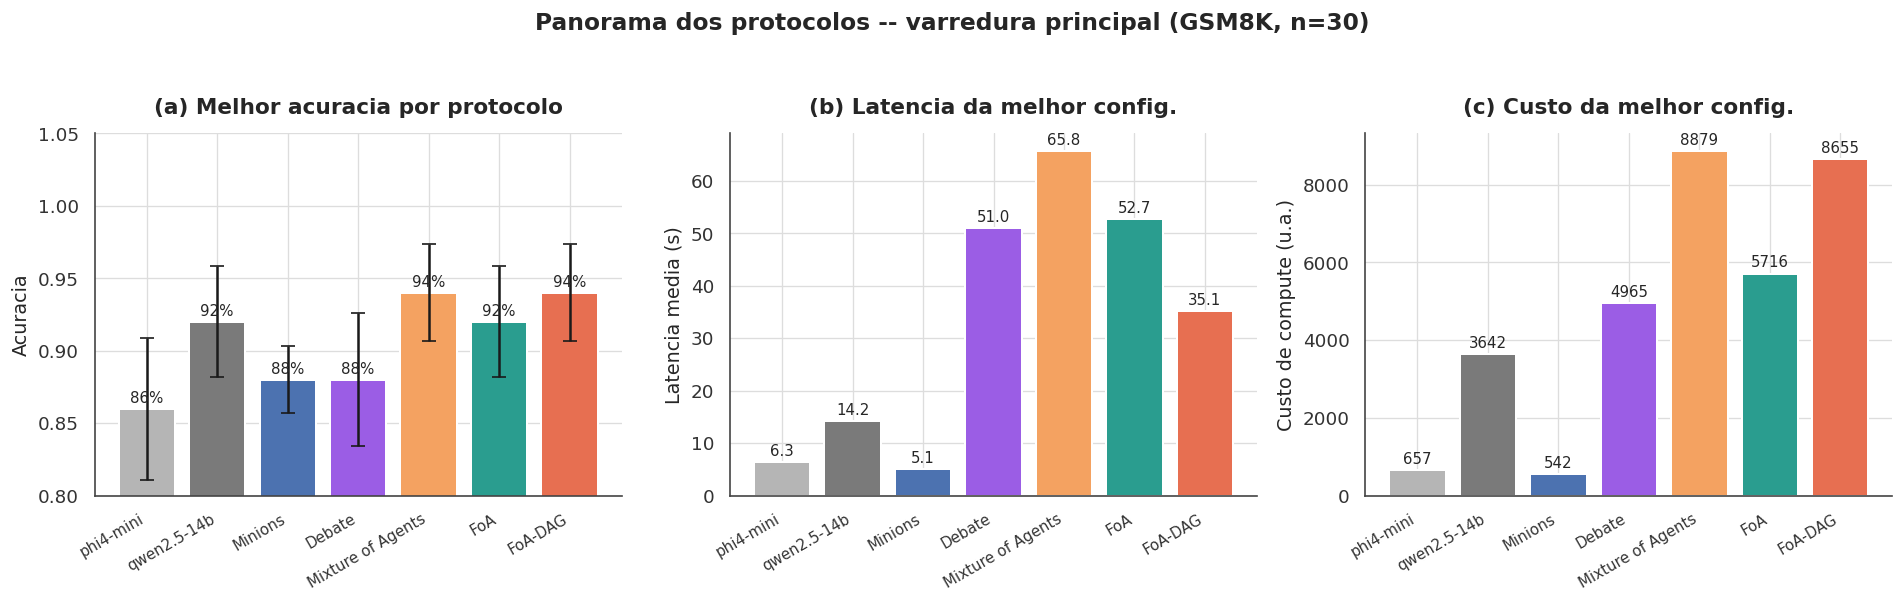

In [4]:
best_others = (sum_main[sum_main["protocol"] != "single_agent"]
    .sort_values("accuracy", ascending=False)
    .groupby("protocol", as_index=False)
    .first())
best_others["proto_label"] = best_others["protocol"].map(PROTOCOL_LABELS)

# single_agent: mantemos cada modelo (phi4-mini, qwen2.5-14b) como barra separada,
# em vez de colapsar no melhor config sob o rotulo generico "Single Agent"
single_agent = sum_main[sum_main["protocol"] == "single_agent"].copy()
single_agent = single_agent.sort_values("minion_params_b")
single_agent["proto_label"] = single_agent["minion"]

others_order = [p for p in ["minions", "debate", "mixture_of_agents", "foa", "foa_dag"] if p in best_others["protocol"].values]
best_others = best_others.set_index("protocol").reindex(others_order).reset_index()
order = ["single_agent"] + others_order

best = pd.concat([single_agent, best_others], ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
sa_palette = sns.color_palette("Greys", n_colors=len(single_agent)+2)[1:-1]
colors = list(sa_palette) + [PROTOCOL_COLORS[p] for p in best_others["protocol"]]
labels = best["proto_label"]

# (a) acuracia com IC binomial
acc, n = best["accuracy"].values, best["n"].values
err = np.sqrt(acc*(1-acc)/n)
b = axes[0].bar(labels, acc, yerr=err, capsize=4, color=colors, edgecolor="white", linewidth=1.2)
axes[0].set_ylim(0.8, 1.05); axes[0].set_ylabel("Acuracia")
axes[0].set_title("(a) Melhor acuracia por protocolo")
bar_labels(axes[0], b, "{:.0%}", fontsize=9)

# (b) latencia media
b = axes[1].bar(labels, best["avg_latency_s"], color=colors, edgecolor="white", linewidth=1.2)
axes[1].set_ylabel("Latencia media (s)")
axes[1].set_title("(b) Latencia da melhor config.")
bar_labels(axes[1], b, "{:.1f}", fontsize=9)

# (c) custo de compute
b = axes[2].bar(labels, best["avg_compute_cost"], color=colors, edgecolor="white", linewidth=1.2)
axes[2].set_ylabel("Custo de compute (u.a.)")
axes[2].set_title("(c) Custo da melhor config.")
bar_labels(axes[2], b, "{:.0f}", fontsize=9)

for ax in axes:
    style_ax(ax)
    ax.tick_params(axis="x")
    ax.set_xticklabels(labels, rotation=30, ha="right", fontsize=9)
fig.suptitle("Panorama dos protocolos -- varredura principal (GSM8K, n=30)",
             fontsize=14, fontweight="bold", y=1.04)
plt.tight_layout()
plt.savefig(FIG_DIR / "panorama_protocolos.png")
plt.show()


### Trade-off global: acurácia × latência × custo

Cada ponto é uma configuração de `runs/`. A posição mostra latência × acurácia;
o **tamanho** codifica o custo de compute e a **cor** o protocolo. Pontos no
canto superior-esquerdo (alta acurácia, baixa latência) são preferíveis.

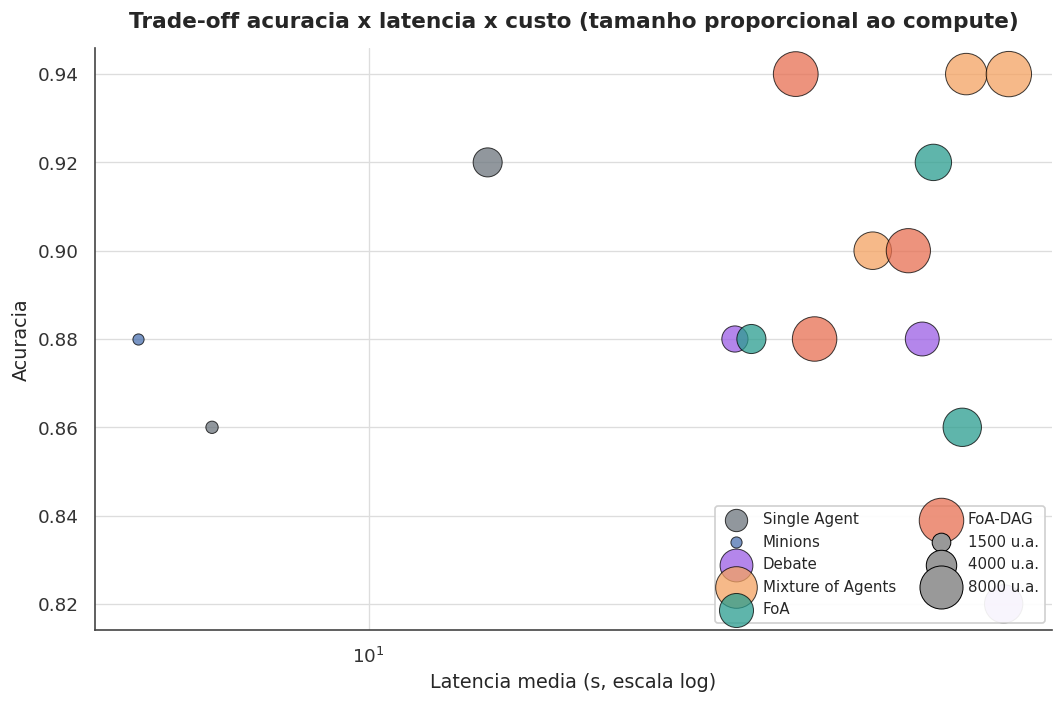

In [5]:
fig, ax = plt.subplots(figsize=(9, 6))
for proto in order:
    sub = sum_main[sum_main.protocol == proto]
    ax.scatter(sub["avg_latency_s"], sub["accuracy"],
               s=sub["avg_compute_cost"]/12, c=PROTOCOL_COLORS[proto],
               alpha=0.75, edgecolor="black", linewidth=0.6,
               label=PROTOCOL_LABELS[proto])
ax.set_xscale("log")
ax.set_xlabel("Latencia media (s, escala log)")
ax.set_ylabel("Acuracia")
ax.set_title("Trade-off acuracia x latencia x custo (tamanho proporcional ao compute)")
# legenda de tamanho
for cost in [1500, 4000, 8000]:
    ax.scatter([], [], s=cost/12, c="#999999", edgecolor="black",
               linewidth=0.6, label=f"{cost} u.a.")
h, l = ax.get_legend_handles_labels()
ax.legend(h, l, loc="lower right", ncol=2, fontsize=9)
style_ax(ax)
plt.tight_layout()
plt.savefig(FIG_DIR / "tradeoff_global.png")
plt.show()


### 3.1 O custo está correto? Nem todo token custa igual

A métrica `compute_cost` já pondera por **tamanho do modelo** (`params_b × tokens`,
não só contagem de tokens) — um token do `qwen2.5-14b` já "pesava" ~3,7x mais que
um token do `phi4-mini`, e um token do `qwen2.5-32b` ~8,4x mais. Isso já estava
certo.

Mas havia um **bug real**: o código só contava `completion_tokens` (saída),
ignorando `prompt_tokens` (entrada). Isso é grave justamente nos protocolos
multiagente — em `foa_dag` e `debate`, cada agente lê as respostas dos outros
antes de gerar a sua, então o prompt costuma ser **maior que a própria
resposta**. Já corrigimos o bug em `src/llm.py` (`compute_cost` agora usa
`total_tokens = prompt + completion`) para as próximas execuções.

Para os experimentos **já rodados**, reconstruímos o custo corrigido diretamente
do `raw.json` já salvo, sem precisar rodar os modelos de novo:

- **`foa`, `foa_dag`, `mixture_of_agents`**: o `extra.agent_costs` guarda
  `prompt_tokens`/`completion_tokens` exatos de cada SLM da frota. O(s)
  call(s) do master não aparecem ali, mas sobram por diferença:
  `master_total = total_tokens − Σ(prompt+completion dos SLMs)`. **Exato.**
- **`single_agent`**: uma única chamada, sempre contabilizada como "master" →
  `total_tokens` pertence 100% a esse modelo. **Exato.**
- **`debate`**: nunca usa master → `total_tokens` pertence 100% ao modelo dos
  debatedores. **Exato.**
- **`minions`** sem delegação (a maioria das perguntas, como você notou): só o
  minion rodou → `total_tokens` é 100% dele. **Exato.** Quando delegou (minion
  + master), só sabemos os tokens de *saída* de cada um — o prompt combinado é
  dividido proporcionalmente à saída de cada papel como aproximação (poucas
  perguntas, efeito pequeno no agregado).

O gráfico abaixo decompõe o custo por **modelo** (não só por protocolo) e
compara o valor antigo (só completion) com o corrigido (completion + prompt).

In [6]:
PARAMS_B = {"qwen2.5-32b": 32.0, "qwen2.5-14b": 14.0, "qwen3-4b": 4.0, "phi4-mini": 3.8}

def role_tokens(row):
    """(minion_total_tokens, master_total_tokens, exato?) reconstruidos do raw.json
    -- ver explicacao na celula markdown acima."""
    total, mt, qt = row["total_tokens"], row["master_tokens"], row["minion_tokens"]
    proto = row["protocol"]
    acosts = row["agent_costs"]

    if isinstance(acosts, list) and acosts:
        minion_total = sum(a["prompt_tokens"] + a["completion_tokens"] for a in acosts)
        master_total = total - minion_total
        return minion_total, master_total, True

    if proto == "single_agent":
        return 0.0, total, True
    if proto == "debate":
        return total, 0.0, True
    if proto == "minions":
        if mt == 0:
            return total, 0.0, True
        prompt_total = total - mt - qt
        share = qt / (qt + mt) if (qt + mt) > 0 else 0.5
        return qt + prompt_total * share, mt + prompt_total * (1 - share), False

    # fallback (nao deveria ocorrer nos protocolos cobertos acima)
    prompt_total = total - mt - qt
    share = qt / (qt + mt) if (qt + mt) > 0 else 0.5
    return qt + prompt_total * share, mt + prompt_total * (1 - share), False

raw_all = pd.concat([raw_main, raw_bak], ignore_index=True)
roles = raw_all.apply(role_tokens, axis=1, result_type="expand")
roles.columns = ["minion_total_tokens", "master_total_tokens", "exact"]
raw_all = pd.concat([raw_all, roles], axis=1)

raw_all["minion_params_b"] = raw_all["minion"].map(PARAMS_B)
raw_all["master_params_b"] = raw_all["master"].map(PARAMS_B)
raw_all["minion_cost_fixed"] = raw_all["minion_params_b"] * raw_all["minion_total_tokens"]
raw_all["master_cost_fixed"] = raw_all["master_params_b"] * raw_all["master_total_tokens"]
raw_all["compute_cost_fixed"] = raw_all["minion_cost_fixed"] + raw_all["master_cost_fixed"]

exact_rate = raw_all["exact"].mean()
print(f"Correcao exata em {exact_rate:.1%} das perguntas "
      f"(o resto -- delegacao no Minions -- usa aproximacao proporcional).")

cost_compare = (raw_all.groupby(["protocol", "minion", "master"])
    .agg(custo_antigo=("compute_cost", "mean"),
         custo_corrigido=("compute_cost_fixed", "mean"),
         custo_minion=("minion_cost_fixed", "mean"),
         custo_master=("master_cost_fixed", "mean"))
    .reset_index())
cost_compare["aumento_pct"] = 100 * (cost_compare["custo_corrigido"] / cost_compare["custo_antigo"] - 1)
cost_compare["config"] = cost_compare["minion"] + " -> " + cost_compare["master"]
cost_compare.sort_values("aumento_pct", ascending=False)[
    ["protocol", "config", "custo_antigo", "custo_corrigido", "aumento_pct"]
].reset_index(drop=True)


Correcao exata em 82.1% das perguntas (o resto -- delegacao no Minions -- usa aproximacao proporcional).


,protocol,config,custo_antigo,custo_corrigido,aumento_pct
0,foa,phi4-mini -> qwen2.5-14b,5242.405333,23162.148000,341.822914
1,mixture_of_agents,phi4-mini -> qwen2.5-14b,7462.229333,28773.922667,285.594189
2,foa_dag,phi4-mini -> qwen2.5-14b,8545.506667,32067.256000,275.252835
3,debate,phi4-mini -> phi4-mini,4753.698667,15494.044000,225.936604
4,foa,qwen3-4b -> qwen2.5-32b,11480.420000,31470.261167,174.121166
5,debate,qwen3-4b -> qwen3-4b,7846.020000,17547.450000,123.647786
6,minions,phi4-mini -> qwen2.5-14b,601.099200,1149.788800,91.281040
7,minions,phi4-mini -> qwen2.5-32b,541.956000,1022.922000,88.746319
8,single_agent,phi4-mini -> phi4-mini,660.926400,994.536000,50.476059
9,single_agent,qwen2.5-14b -> qwen2.5-14b,3615.528000,4991.504000,38.057401


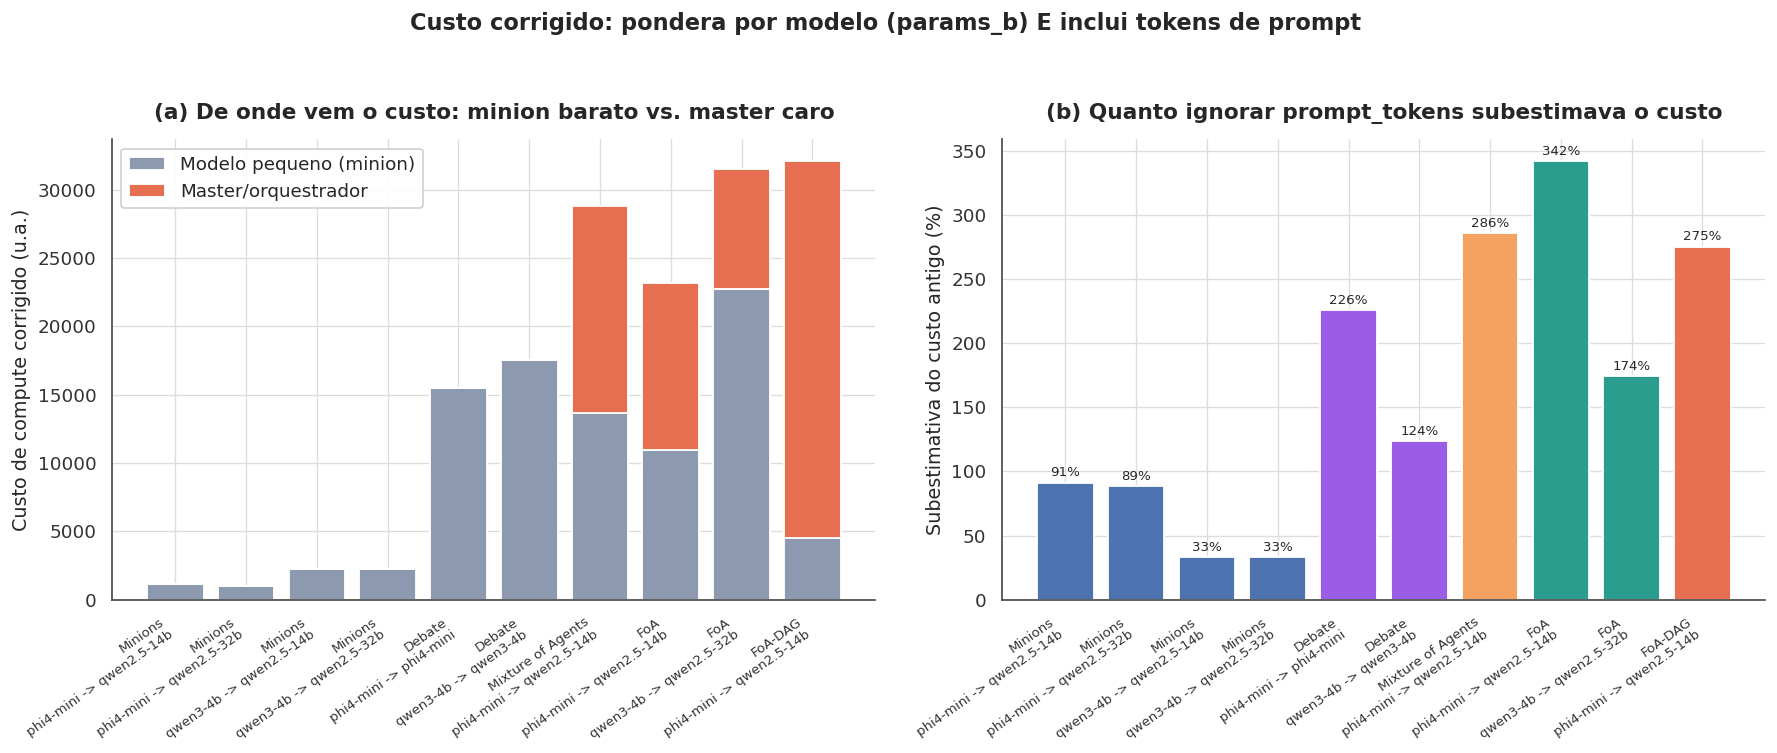

In [7]:
proto_order = ["minions", "debate", "mixture_of_agents", "foa", "foa_dag"]
cc = cost_compare[cost_compare["protocol"] != "single_agent"].copy()
cc["label"] = cc["protocol"].map(PROTOCOL_LABELS) + "\n" + cc["config"]
cc["protocol"] = pd.Categorical(cc["protocol"], categories=proto_order, ordered=True)
cc = cc.sort_values(["protocol", "config"])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# (a) custo corrigido decomposto: quanto vem do modelo pequeno vs do master
x = np.arange(len(cc))
axes[0].bar(x, cc["custo_minion"], color="#8d99ae", edgecolor="white",
            linewidth=1.1, label="Modelo pequeno (minion)")
axes[0].bar(x, cc["custo_master"], bottom=cc["custo_minion"], color="#E76F51",
            edgecolor="white", linewidth=1.1, label="Master/orquestrador")
axes[0].set_xticks(x); axes[0].set_xticklabels(cc["label"], rotation=35, ha="right", fontsize=8)
axes[0].set_ylabel("Custo de compute corrigido (u.a.)")
axes[0].set_title("(a) De onde vem o custo: minion barato vs. master caro")
axes[0].legend()
style_ax(axes[0])

# (b) quanto o bug (so completion) subestimava o custo real
colors_b = [PROTOCOL_COLORS[p] for p in cc["protocol"]]
b = axes[1].bar(x, cc["aumento_pct"], color=colors_b, edgecolor="white", linewidth=1.1)
bar_labels(axes[1], b, "{:.0f}%", fontsize=8)
axes[1].set_xticks(x); axes[1].set_xticklabels(cc["label"], rotation=35, ha="right", fontsize=8)
axes[1].set_ylabel("Subestimativa do custo antigo (%)")
axes[1].set_title("(b) Quanto ignorar prompt_tokens subestimava o custo")
style_ax(axes[1])

fig.suptitle("Custo corrigido: pondera por modelo (params_b) E inclui tokens de prompt",
             fontsize=13.5, fontweight="bold", y=1.04)
plt.tight_layout()
plt.savefig(FIG_DIR / "custo_corrigido_por_modelo.png")
plt.show()


> **Leitura.** O custo antigo (só completion) estava **subestimado em 20–340%**,
> dependendo do protocolo:
> - **Debate** e **FoA/FoA-DAG** foram os mais afetados (+124% a +342%) — exatamente
>   os protocolos onde cada agente lê respostas de outros agentes antes de gerar a
>   sua, então o prompt é grande e crescia sem ser contado.
> - **Minions** foi o menos afetado (+33% a +91%) — consistente com o que você
>   notou: o master só é chamado numa fração das perguntas, então o custo do
>   modelo caro (`qwen2.5-14b`/`qwen2.5-32b`) pesa pouco no agregado.
> - Mesmo o **Single Agent**, com uma única chamada, estava subestimado
>   (+22% a +50%) simplesmente por ignorar o prompt.
> - O painel (a) mostra que, no `foa`/`foa_dag`/`mixture_of_agents`, boa parte do
>   custo real vem do **master** (qwen2.5-14b) mesmo quando ele é chamado uma
>   única vez por pergunta — cada token dele já "pesa" 3,7x mais que um token do
>   `phi4-mini`, e ele processa um prompt longo (todas as respostas da frota).

## 4. Mergulho no FoA — efeito do número de agentes `n`

O **Fleet of Agents (FoA)** executa `n` minions em paralelo e um master
agrega/concilia. A pergunta central: **vale a pena aumentar `n`?**
Isolamos as configurações `foa` da varredura principal, que cobrem `n in {2,3,4}`
para diferentes pares (minion -> master).

In [8]:
foa = sum_main[sum_main.protocol == "foa"].copy()
foa["config"] = foa["minion"] + " -> " + foa["master"]
foa = foa.sort_values(["config", "n_minions"])
foa_raw = raw_main[raw_main.protocol == "foa"].copy()
foa_raw["config"] = foa_raw["minion"] + " -> " + foa_raw["master"]

configs = sorted(foa["config"].unique())
cfg_colors = dict(zip(configs, sns.color_palette("rocket_r", len(configs))))
print("Configuracoes FoA:", configs)
foa[["config","n_minions","accuracy","avg_latency_s","avg_total_tokens",
     "avg_compute_cost","avg_model_calls","avg_master_tokens"]].reset_index(drop=True)


Configuracoes FoA: ['phi4-mini -> qwen2.5-14b']


,config,n_minions,accuracy,avg_latency_s,avg_total_tokens,avg_compute_cost,avg_model_calls,avg_master_tokens
0,phi4-mini -> qwen2.5-14b,2,0.88,30.840261,2065.56,3655.076,3.96,111.46
1,phi4-mini -> qwen2.5-14b,3,0.92,52.680928,4213.80,5716.032,6.52,122.68
2,phi4-mini -> qwen2.5-14b,4,0.86,57.355416,4975.74,6356.108,7.24,125.02


### 4.1 Acurácia em função de `n`

Linhas conectam a mesma dupla minion→master conforme `n` cresce. Barras de erro são o erro-padrão binomial (n=30).

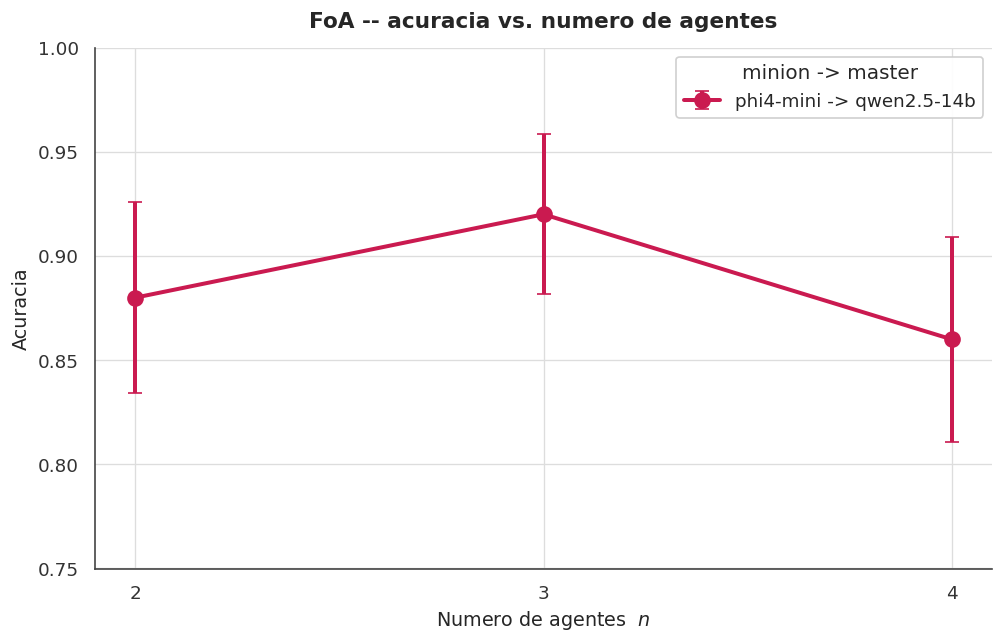

In [9]:
fig, ax = plt.subplots(figsize=(8.5, 5.5))
for cfg in configs:
    sub = foa[foa.config == cfg].sort_values("n_minions")
    acc, nn = sub["accuracy"].values, sub["n"].values
    err = np.sqrt(acc*(1-acc)/nn)
    ax.errorbar(sub["n_minions"], acc, yerr=err, marker="o", markersize=9,
                linewidth=2.4, capsize=4, color=cfg_colors[cfg], label=cfg)
ax.set_xticks([2, 3, 4])
ax.set_xlabel("Numero de agentes  $n$")
ax.set_ylabel("Acuracia")
ax.set_ylim(0.75, 1.0)
ax.set_title("FoA -- acuracia vs. numero de agentes")
ax.legend(title="minion -> master")
style_ax(ax)
plt.tight_layout()
plt.savefig(FIG_DIR / "foa_acc_vs_n.png")
plt.show()


> **Leitura.** Aumentar `n` **não** melhora a acurácia de forma monótona:
> em vários pares o ganho satura ou até regride em `n=4`. O master mais forte
> (`qwen2.5-14b`) sustenta melhor a acurácia do que o master fraco
> (`phi4-mini`), sugerindo que o gargalo é a *agregação*, não a quantidade de
> rascunhos.

### 4.2 O custo de crescer `n` — latência, tokens, compute e chamadas

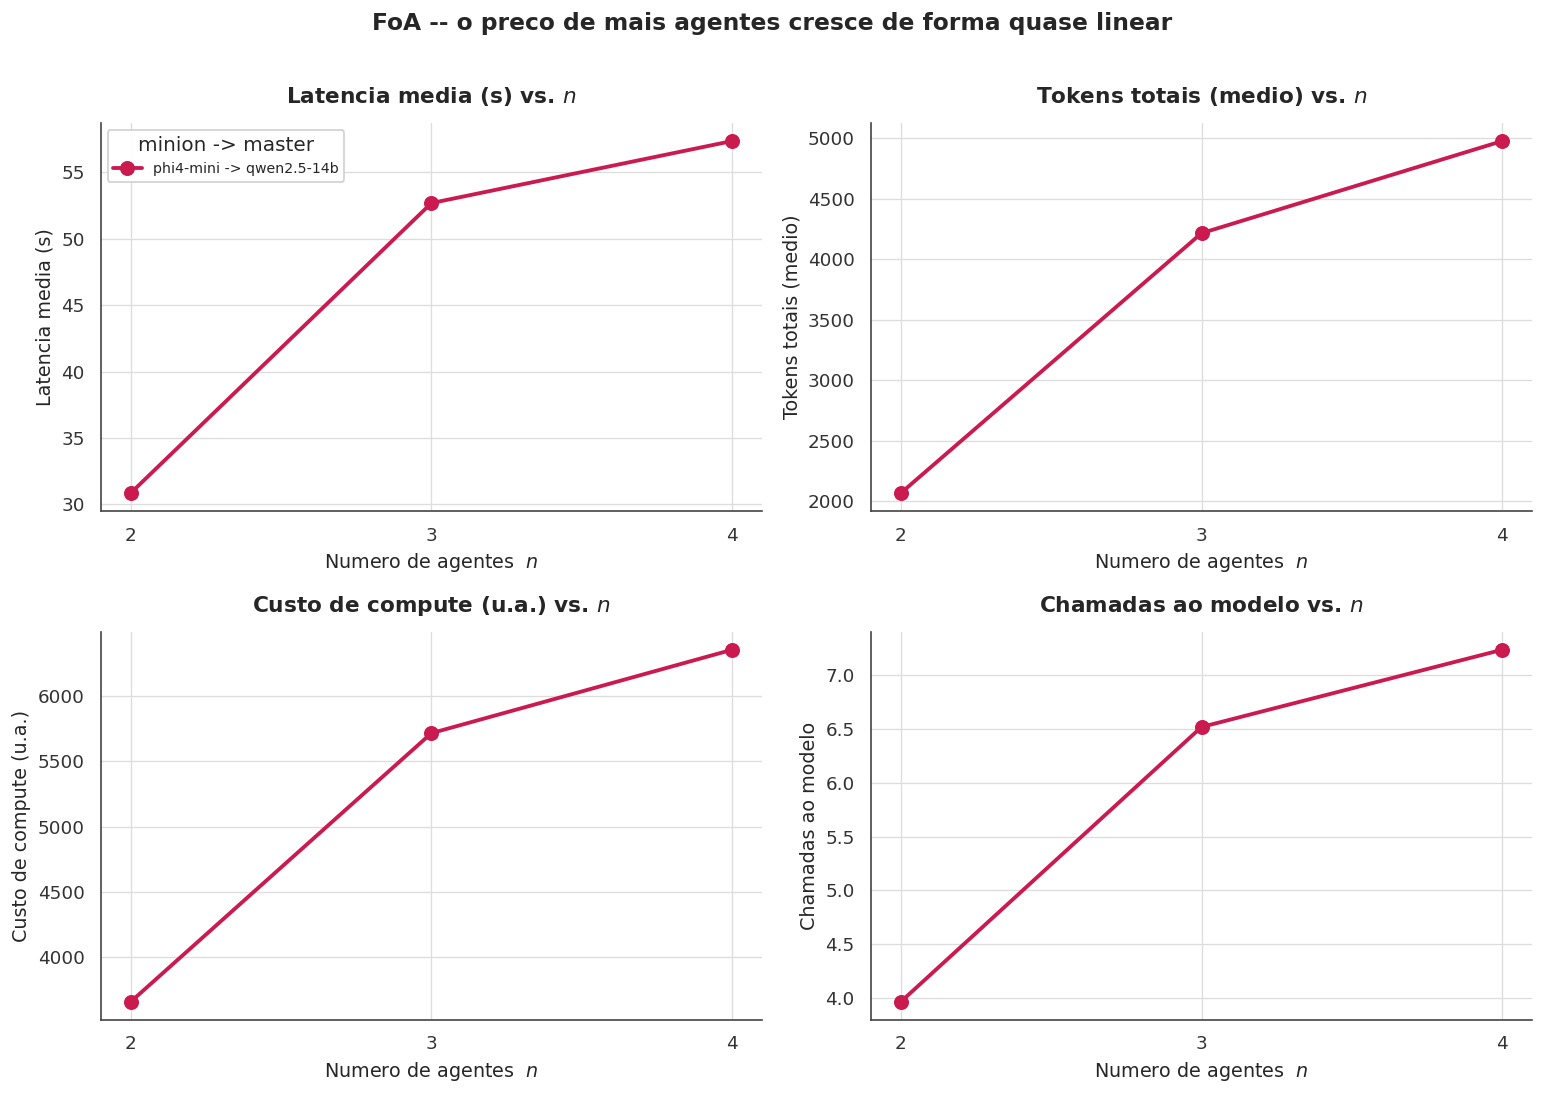

In [10]:
metrics = [
    ("avg_latency_s", "Latencia media (s)", "{:.1f}"),
    ("avg_total_tokens", "Tokens totais (medio)", "{:.0f}"),
    ("avg_compute_cost", "Custo de compute (u.a.)", "{:.0f}"),
    ("avg_model_calls", "Chamadas ao modelo", "{:.1f}"),
]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (col, ylab, _) in zip(axes.flat, metrics):
    for cfg in configs:
        sub = foa[foa.config == cfg].sort_values("n_minions")
        ax.plot(sub["n_minions"], sub[col], marker="o", markersize=8,
                linewidth=2.3, color=cfg_colors[cfg], label=cfg)
    ax.set_xticks([2, 3, 4]); ax.set_xlabel("Numero de agentes  $n$")
    ax.set_ylabel(ylab); ax.set_title(ylab + " vs. $n$")
    style_ax(ax)
axes.flat[0].legend(title="minion -> master", fontsize=8.5)
fig.suptitle("FoA -- o preco de mais agentes cresce de forma quase linear",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIG_DIR / "foa_custos_vs_n.png")
plt.show()


### 4.3 Eficiência: acurácia entregue por unidade de custo

Crescer `n` quase sempre aumenta o custo, então a métrica relevante é a
**acurácia por recurso gasto**. Valores mais altos = melhor aproveitamento.

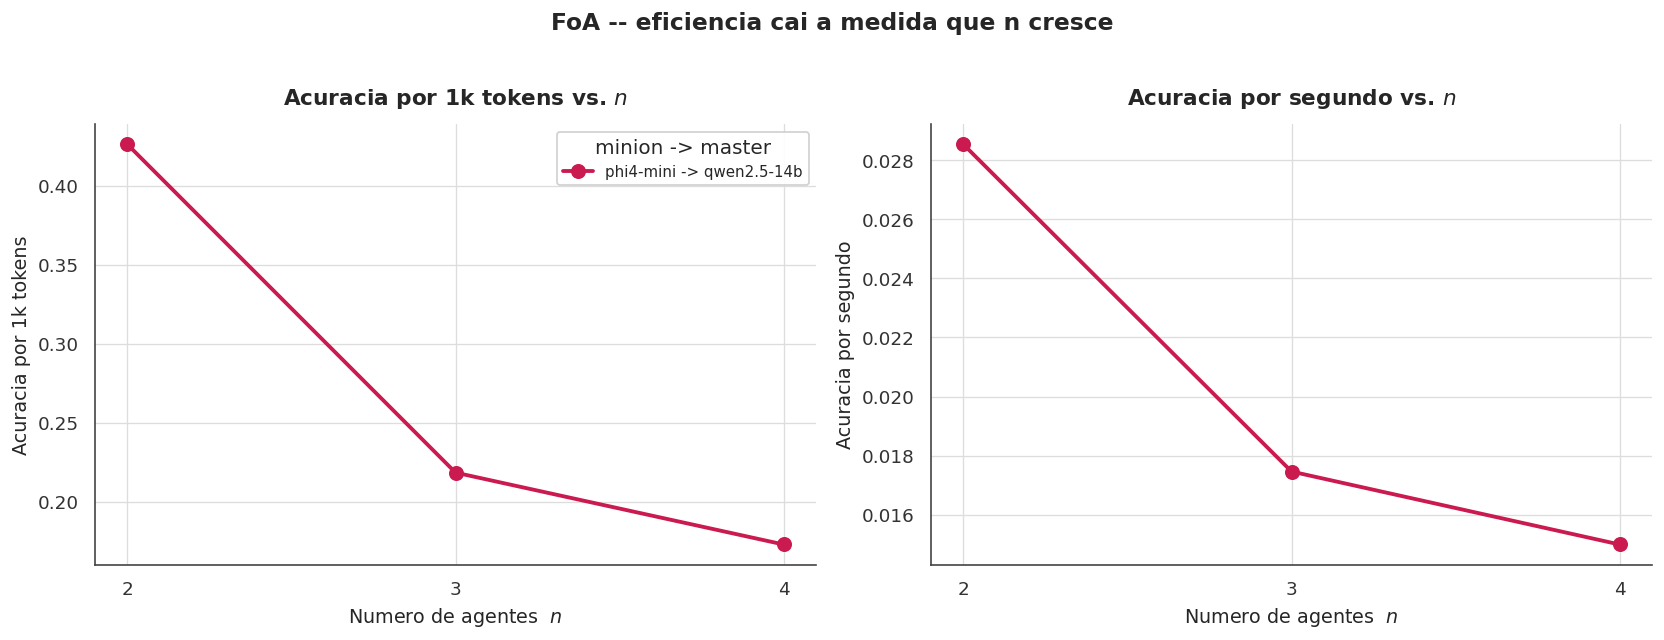

In [11]:
foa["acc_per_1k_tokens"] = foa["accuracy"] / (foa["avg_total_tokens"]/1000)
foa["acc_per_sec"] = foa["accuracy"] / foa["avg_latency_s"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
for ax, col, ylab in [
    (axes[0], "acc_per_1k_tokens", "Acuracia por 1k tokens"),
    (axes[1], "acc_per_sec", "Acuracia por segundo"),
]:
    for cfg in configs:
        sub = foa[foa.config == cfg].sort_values("n_minions")
        ax.plot(sub["n_minions"], sub[col], marker="o", markersize=8,
                linewidth=2.3, color=cfg_colors[cfg], label=cfg)
    ax.set_xticks([2, 3, 4]); ax.set_xlabel("Numero de agentes  $n$")
    ax.set_ylabel(ylab); ax.set_title(ylab + " vs. $n$")
    style_ax(ax)
axes[0].legend(title="minion -> master", fontsize=9)
fig.suptitle("FoA -- eficiencia cai a medida que n cresce",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "foa_eficiencia_vs_n.png")
plt.show()


### 4.4 Distribuições por pergunta — variabilidade conforme `n`

Médias escondem a dispersão. Usando `raw.json`, mostramos a distribuição de latência e tokens por pergunta para a melhor dupla (`phi4-mini → qwen2.5-14b`).

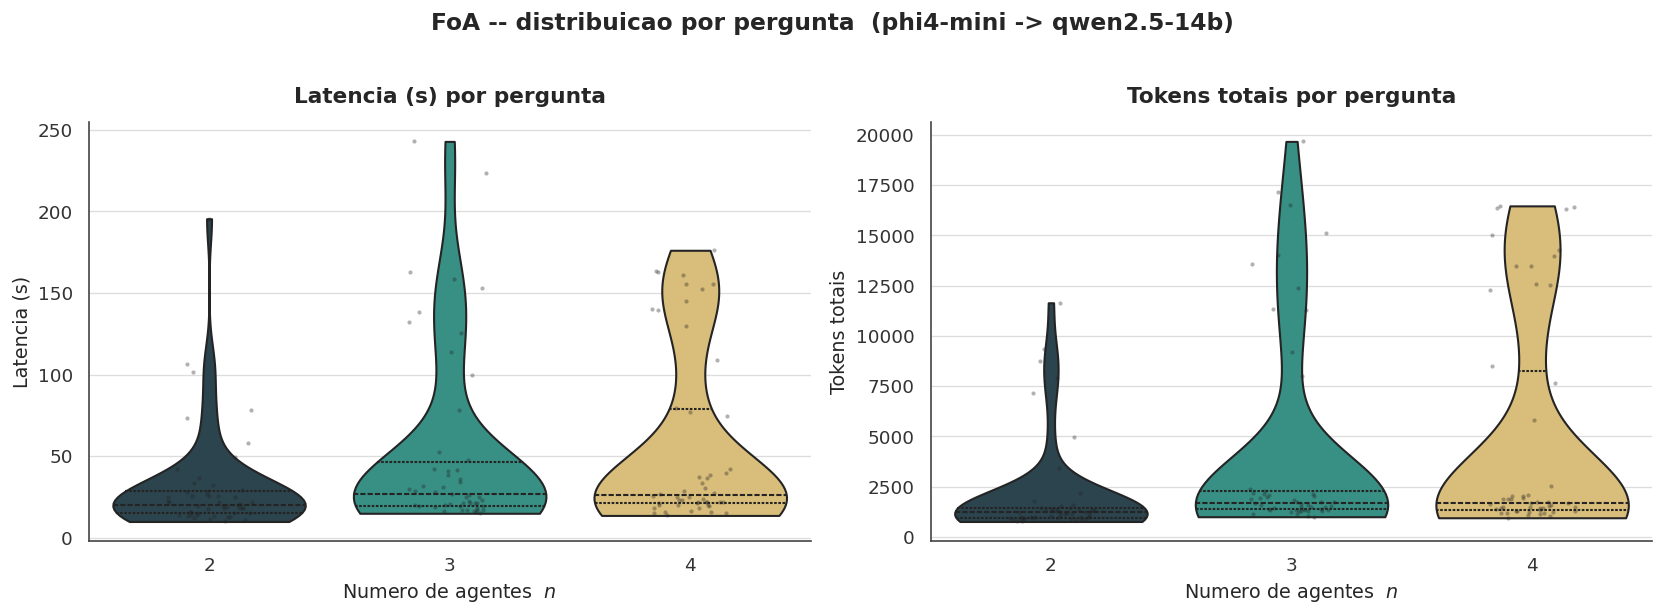

In [12]:
focus_cfg = "phi4-mini -> qwen2.5-14b"
sub = foa_raw[foa_raw.config == focus_cfg].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, ylab in [
    (axes[0], "latency_s", "Latencia (s)"),
    (axes[1], "total_tokens", "Tokens totais"),
]:
    sns.violinplot(data=sub, x="n_minions", y=col, ax=ax,
                   hue="n_minions", legend=False,
                   palette=[N_PALETTE[n] for n in sorted(sub.n_minions.unique())],
                   inner="quartile", cut=0)
    sns.stripplot(data=sub, x="n_minions", y=col, ax=ax, color="#222222",
                  size=2.5, alpha=0.35, jitter=0.18)
    ax.set_xlabel("Numero de agentes  $n$"); ax.set_ylabel(ylab)
    ax.set_title(f"{ylab} por pergunta")
    style_ax(ax)
fig.suptitle(f"FoA -- distribuicao por pergunta  ({focus_cfg})",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / "foa_distribuicoes_vs_n.png")
plt.show()


### 4.5 Pareto: acurácia × custo, anotado por `n`

A fronteira de Pareto revela se algum `n` adicional "paga" o custo extra.

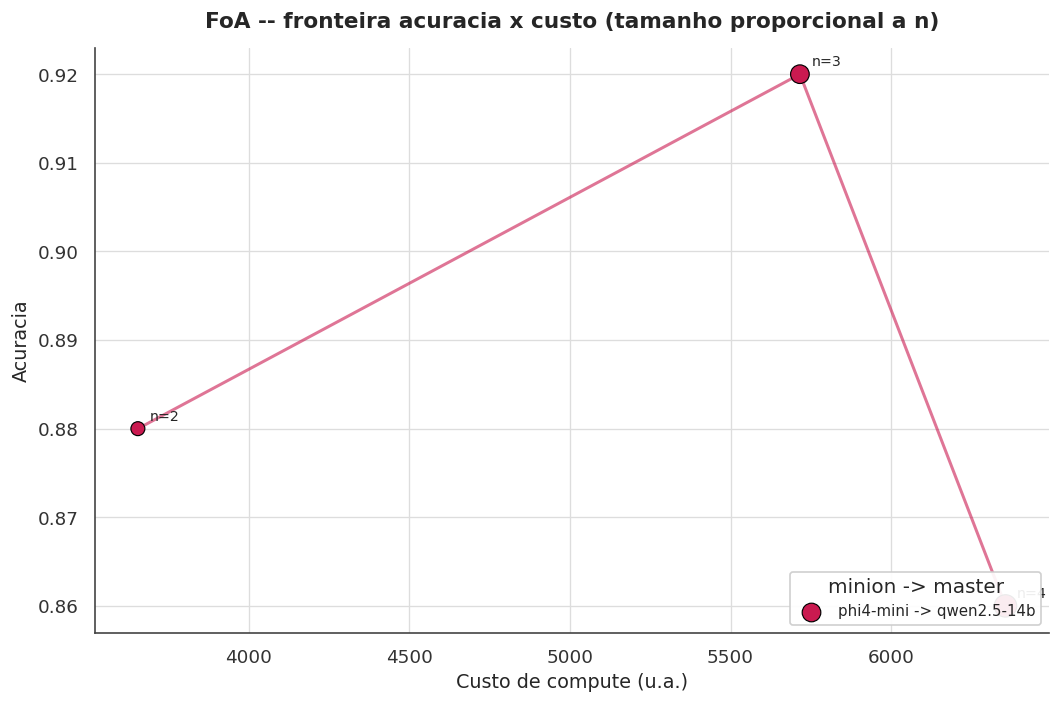

In [13]:
fig, ax = plt.subplots(figsize=(9, 6))
for cfg in configs:
    sub = foa[foa.config == cfg].sort_values("n_minions")
    ax.plot(sub["avg_compute_cost"], sub["accuracy"], "-", color=cfg_colors[cfg],
            alpha=0.6, linewidth=1.8, zorder=1)
    ax.scatter(sub["avg_compute_cost"], sub["accuracy"],
               s=[70+55*(n-2) for n in sub["n_minions"]],
               color=cfg_colors[cfg], edgecolor="black", linewidth=0.7,
               label=cfg, zorder=2)
    for _, r in sub.iterrows():
        ax.annotate(f"n={r['n_minions']}", (r["avg_compute_cost"], r["accuracy"]),
                    textcoords="offset points", xytext=(7, 5), fontsize=8.5)
ax.set_xlabel("Custo de compute (u.a.)")
ax.set_ylabel("Acuracia")
ax.set_title("FoA -- fronteira acuracia x custo (tamanho proporcional a n)")
ax.legend(title="minion -> master", loc="lower right", fontsize=9)
style_ax(ax)
plt.tight_layout()
plt.savefig(FIG_DIR / "foa_pareto.png")
plt.show()


## 5. FoA vs FoA-DAG e o custo por agente

O **FoA-DAG** organiza os agentes num grafo de dependências em vez de um
*fleet* plano. Comparamos os dois nas duplas em comum e, com `agent_costs.json`,
abrimos o custo **por agente** dentro do FoA-DAG.

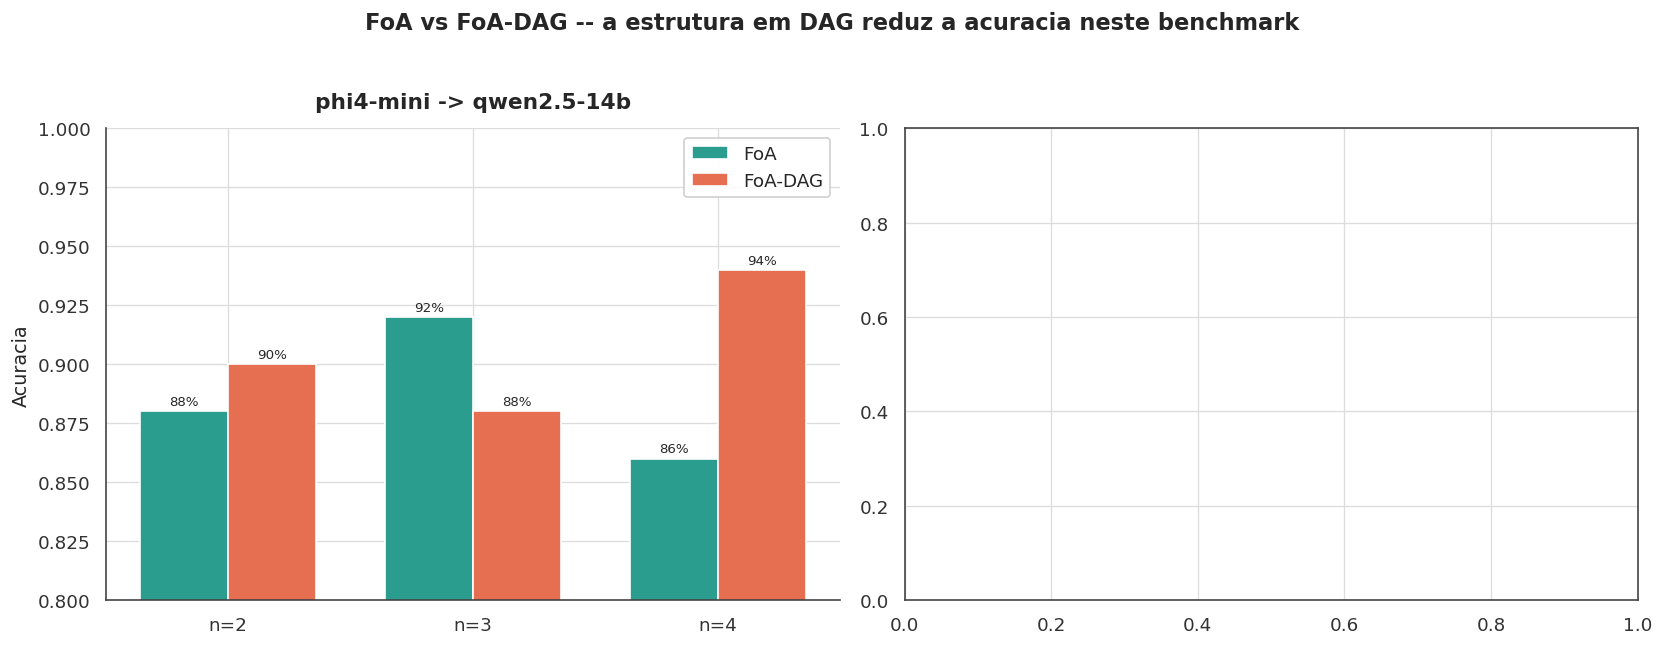

In [14]:
pair = sum_main[sum_main.protocol.isin(["foa", "foa_dag"])].copy()
pair["config"] = pair["minion"] + " -> " + pair["master"]
common = sorted(set(pair[pair.protocol=="foa"].config) &
                set(pair[pair.protocol=="foa_dag"].config))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
width = 0.36
for ax, cfg in zip(axes, common):
    f = pair[(pair.config==cfg) & (pair.protocol=="foa")].sort_values("n_minions")
    d = pair[(pair.config==cfg) & (pair.protocol=="foa_dag")].sort_values("n_minions")
    x = np.arange(len(f))
    b1 = ax.bar(x-width/2, f["accuracy"], width, label="FoA",
                color=PROTOCOL_COLORS["foa"], edgecolor="white")
    b2 = ax.bar(x+width/2, d["accuracy"], width, label="FoA-DAG",
                color=PROTOCOL_COLORS["foa_dag"], edgecolor="white")
    bar_labels(ax, b1, "{:.0%}", fontsize=8); bar_labels(ax, b2, "{:.0%}", fontsize=8)
    ax.set_xticks(x); ax.set_xticklabels([f"n={n}" for n in f["n_minions"]])
    ax.set_ylim(0.8, 1.0); ax.set_ylabel("Acuracia")
    ax.set_title(cfg); ax.legend()
    style_ax(ax)
fig.suptitle("FoA vs FoA-DAG -- a estrutura em DAG reduz a acuracia neste benchmark",
             fontsize=13.5, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig(FIG_DIR / "foa_vs_dag.png")
plt.show()


### 5.1 Custo de compute por agente (FoA-DAG)

`agent_costs.json` traz a participação de cada agente. Mostramos como o custo se distribui à medida que `n` cresce, para `phi4-mini → qwen2.5-14b`.

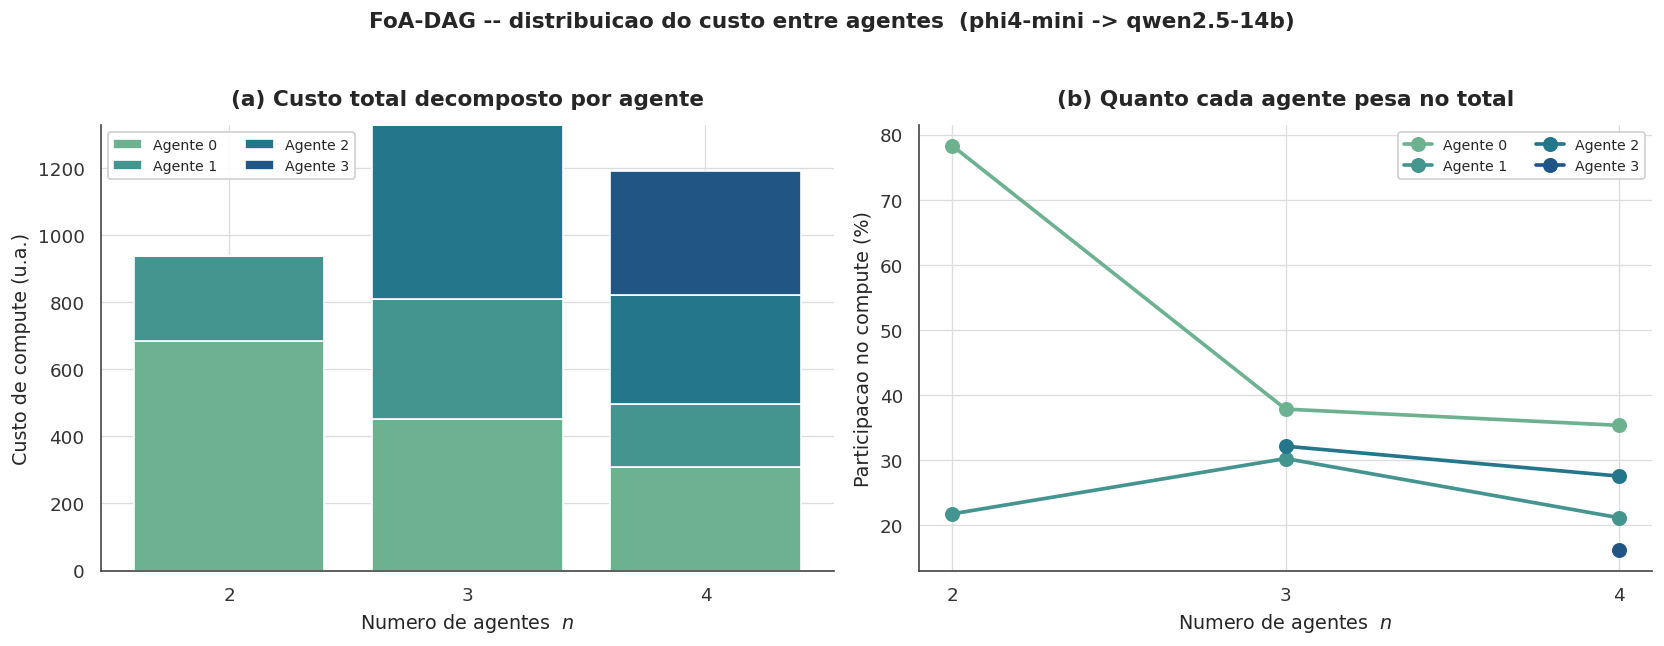

In [15]:
def load_agent_costs(cfg_minion, cfg_master):
    rows = []
    for d in sorted(RUNS_DIR.glob(f"foa_dag__min-{cfg_minion}__mas-{cfg_master}__n*")):
        _, _, _, n = parse_dirname(d.name)
        for a in json.load(open(d / "agent_costs.json", encoding="utf-8")):
            a = dict(a); a["n_minions"] = n; rows.append(a)
    return pd.DataFrame(rows)

ac = load_agent_costs("phi4-mini", "qwen2.5-14b")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
# (a) custo absoluto empilhado por agente
ns = sorted(ac.n_minions.unique())
agent_pal = sns.color_palette("crest", ac.agent.max()+1)
bottom = np.zeros(len(ns))
for ag in range(ac.agent.max()+1):
    vals = [ac[(ac.n_minions==n) & (ac.agent==ag)]["avg_compute_cost"].sum() for n in ns]
    axes[0].bar([str(n) for n in ns], vals, bottom=bottom,
                color=agent_pal[ag], edgecolor="white", label=f"Agente {ag}")
    bottom += np.array(vals)
axes[0].set_xlabel("Numero de agentes  $n$")
axes[0].set_ylabel("Custo de compute (u.a.)")
axes[0].set_title("(a) Custo total decomposto por agente")
axes[0].legend(fontsize=8.5, ncol=2)
style_ax(axes[0])

# (b) participacao relativa (%)
for ag in range(ac.agent.max()+1):
    sub = ac[ac.agent==ag].sort_values("n_minions")
    axes[1].plot(sub["n_minions"], sub["share_compute_pct"], marker="o",
                 markersize=8, linewidth=2.2, color=agent_pal[ag], label=f"Agente {ag}")
axes[1].set_xticks(ns); axes[1].set_xlabel("Numero de agentes  $n$")
axes[1].set_ylabel("Participacao no compute (%)")
axes[1].set_title("(b) Quanto cada agente pesa no total")
axes[1].legend(fontsize=8.5, ncol=2)
style_ax(axes[1])
fig.suptitle("FoA-DAG -- distribuicao do custo entre agentes  (phi4-mini -> qwen2.5-14b)",
             fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig(FIG_DIR / "foa_dag_custo_por_agente.png")
plt.show()


## 6. Dinâmica interna do FoA — consenso e rodadas

O campo `extra` de cada pergunta registra se os agentes chegaram a **consenso**
e em quantas **rodadas**. Isso explica *por que* o custo cresce: sem consenso,
o FoA gasta uma rodada extra de deliberação.

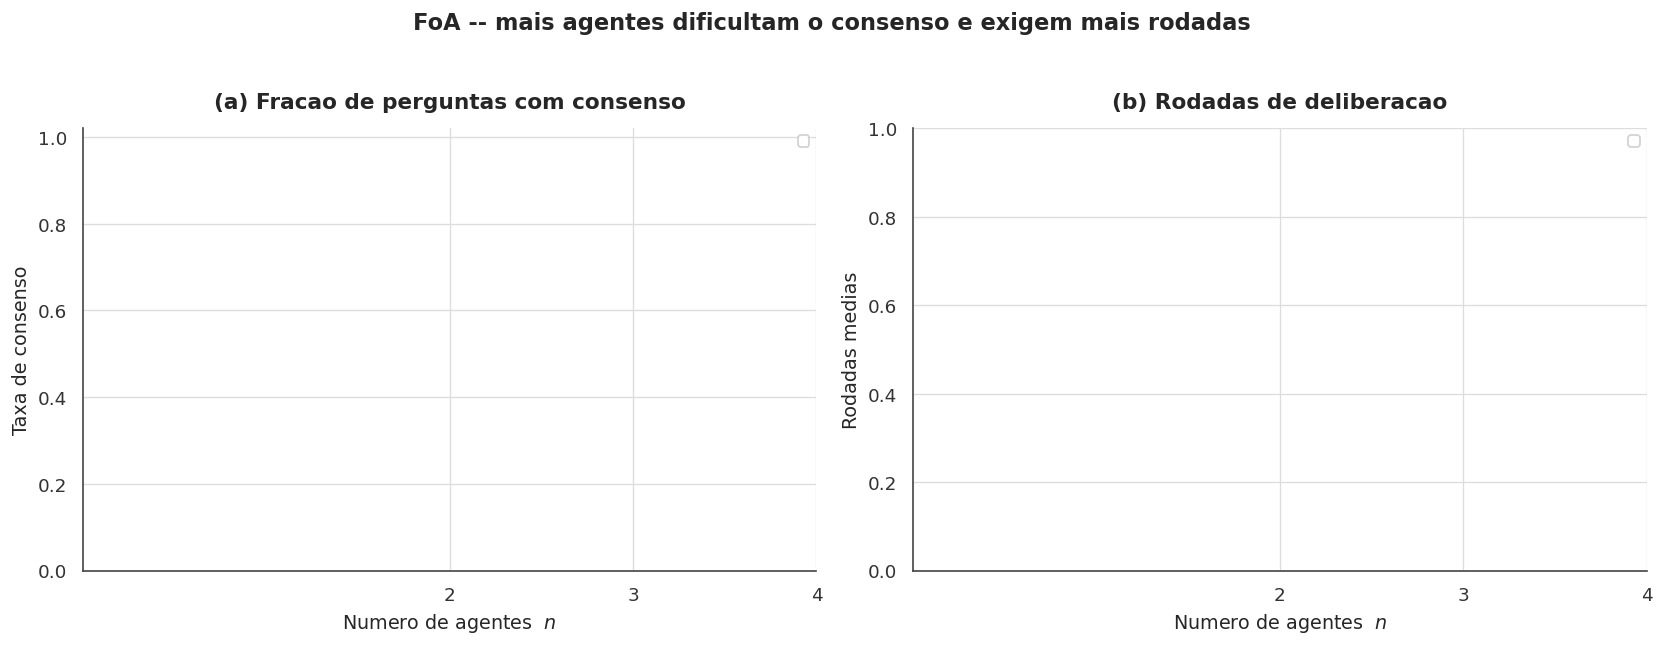

In [16]:
fc = foa_raw.dropna(subset=["consensus"]).copy()
agg = (fc.groupby(["config", "n_minions"])
         .agg(consenso=("consensus", "mean"),
              rodadas=("rounds", "mean"),
              acc=("correct", "mean"))
         .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
for cfg in sorted(agg.config.unique()):
    s = agg[agg.config==cfg].sort_values("n_minions")
    axes[0].plot(s["n_minions"], s["consenso"], marker="o", markersize=8,
                 linewidth=2.3, color=cfg_colors.get(cfg, "#333"), label=cfg)
    axes[1].plot(s["n_minions"], s["rodadas"], marker="s", markersize=8,
                 linewidth=2.3, color=cfg_colors.get(cfg, "#333"), label=cfg)
axes[0].set_ylabel("Taxa de consenso"); axes[0].set_ylim(0, 1.02)
axes[0].set_title("(a) Fracao de perguntas com consenso")
axes[1].set_ylabel("Rodadas medias"); axes[1].set_title("(b) Rodadas de deliberacao")
for ax in axes:
    ax.set_xticks([2,3,4]); ax.set_xlabel("Numero de agentes  $n$")
    ax.legend(fontsize=8.5); style_ax(ax)
fig.suptitle("FoA -- mais agentes dificultam o consenso e exigem mais rodadas",
             fontsize=13.5, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig(FIG_DIR / "foa_consenso_rodadas.png")
plt.show()


### 6.1 Consenso ajuda a acertar?

Comparação direta da acurácia em perguntas **com** vs **sem** consenso, agregando
todas as configurações FoA da varredura principal.

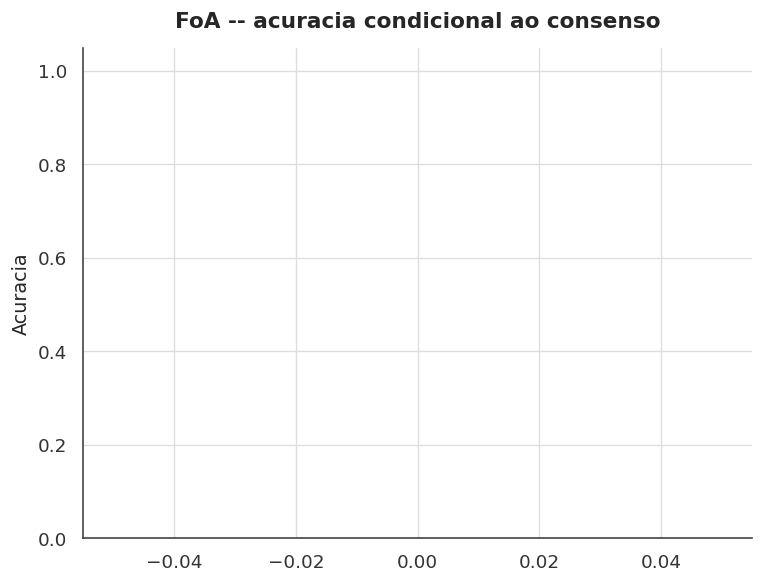

In [17]:
cons = (fc.groupby("consensus")["correct"].agg(["mean", "size"]).reset_index())
cons["label"] = cons["consensus"].map({True: "Com consenso", False: "Sem consenso"})

fig, ax = plt.subplots(figsize=(6.5, 5))
bars = ax.bar(cons["label"], cons["mean"],
              color=["#2A9D8F", "#E76F51"], edgecolor="white", linewidth=1.4, width=0.6)
for b, (_, r) in zip(bars, cons.iterrows()):
    ax.annotate(f"{r['mean']:.0%}\n(n={int(r['size'])})",
                (b.get_x()+b.get_width()/2, b.get_height()),
                ha="center", va="bottom", fontsize=10, xytext=(0,3),
                textcoords="offset points")
ax.set_ylim(0, 1.05); ax.set_ylabel("Acuracia")
ax.set_title("FoA -- acuracia condicional ao consenso")
style_ax(ax)
plt.tight_layout()
plt.savefig(FIG_DIR / "foa_consenso_vs_acuracia.png")
plt.show()


## 7. Seção final — explorando os `backup_runs`

Os `backup_runs` trazem execuções **maiores (n=200)** e mais variadas:
o protocolo de **Debate**, o master grande **qwen2.5-32b** e uma varredura de
modelos *single agent*. Aqui exploramos livremente esses extras, repetindo
alguns formatos de gráfico em escala maior e mais confiável.

In [18]:
print("Configuracoes em backup_runs:")
sum_bak["config"] = sum_bak["minion"] + " -> " + sum_bak["master"]
sum_bak[["protocol","config","n_minions","n","accuracy","avg_latency_s",
         "avg_compute_cost","avg_model_calls"]].sort_values(
            ["protocol","config","n_minions"]).reset_index(drop=True)


Configuracoes em backup_runs:


,protocol,config,n_minions,n,accuracy,avg_latency_s,avg_compute_cost,avg_model_calls
0,debate,qwen3-4b -> qwen3-4b,2,200,0.840,78.839794,6282.900,4.00
1,debate,qwen3-4b -> qwen3-4b,3,200,0.885,114.184547,9409.140,6.00
2,foa,qwen3-4b -> qwen2.5-32b,2,200,0.950,79.065801,9257.840,3.95
3,foa,qwen3-4b -> qwen2.5-32b,3,200,0.940,116.036533,11330.900,5.65
4,foa,qwen3-4b -> qwen2.5-32b,4,200,0.960,145.465983,13852.520,7.44
5,minions,phi4-mini -> qwen2.5-14b,1,50,0.840,7.481775,837.672,1.00
6,minions,phi4-mini -> qwen2.5-32b,1,200,0.880,5.148585,541.956,1.00
7,minions,qwen3-4b -> qwen2.5-14b,1,200,0.730,20.056624,1658.660,1.00
8,minions,qwen3-4b -> qwen2.5-32b,1,200,0.730,22.134504,1658.660,1.00
9,single_agent,phi4-mini -> phi4-mini,1,200,0.905,6.859203,661.789,1.00


### 7.1 FoA com master forte (qwen2.5-32b) — escala de `n` em n=200

Repetimos a análise de escala de `n`, agora com o master grande e amostra 6× maior — barras de erro muito mais estreitas.

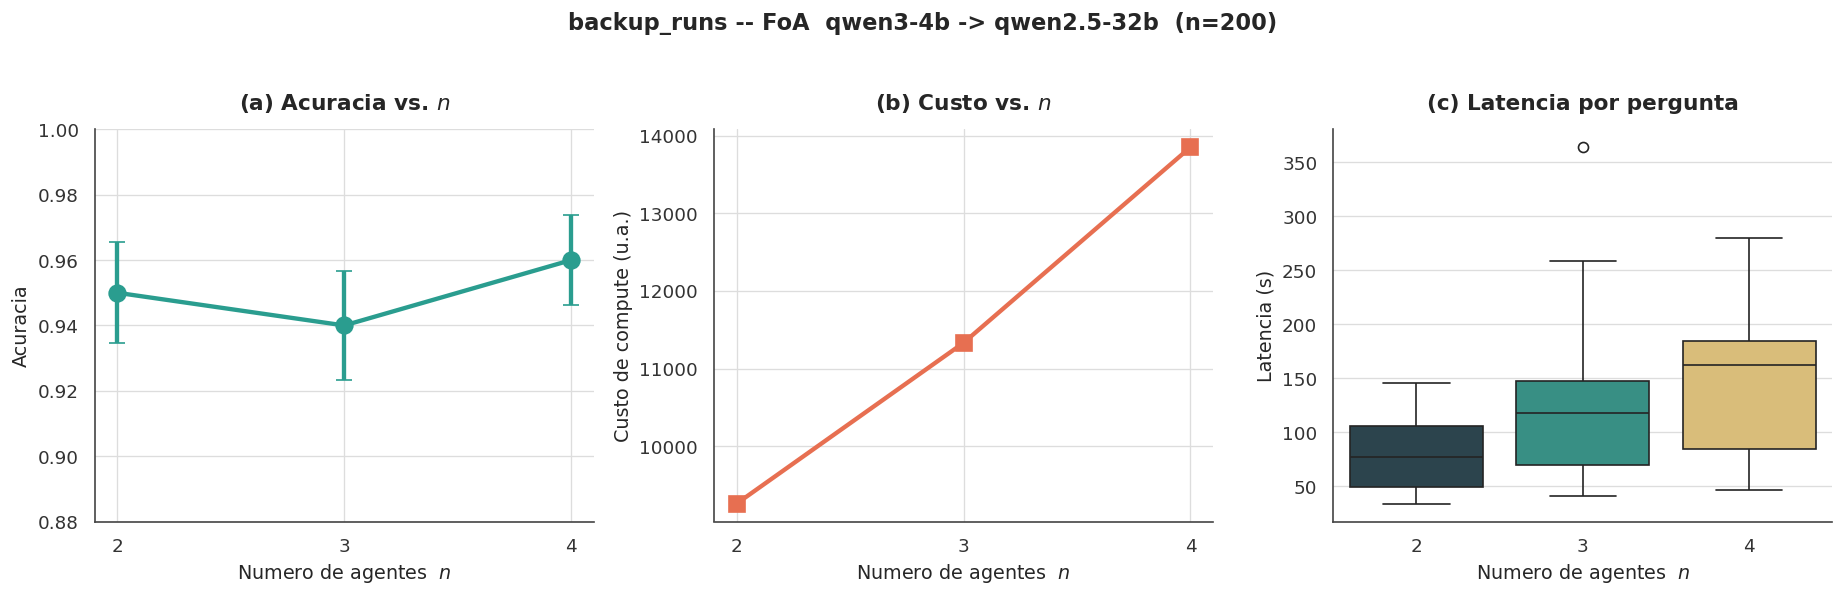

In [19]:
fb = sum_bak[sum_bak.protocol=="foa"].sort_values("n_minions")
rb = raw_bak[raw_bak.protocol=="foa"].copy()

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.8))
# (a) acuracia vs n
acc, nn = fb["accuracy"].values, fb["n"].values
err = np.sqrt(acc*(1-acc)/nn)
axes[0].errorbar(fb["n_minions"], acc, yerr=err, marker="o", markersize=10,
                 linewidth=2.6, capsize=5, color=PROTOCOL_COLORS["foa"])
axes[0].set_ylim(0.88, 1.0); axes[0].set_xticks([2,3,4])
axes[0].set_xlabel("Numero de agentes  $n$"); axes[0].set_ylabel("Acuracia")
axes[0].set_title("(a) Acuracia vs. $n$")
# (b) custo vs n
axes[1].plot(fb["n_minions"], fb["avg_compute_cost"], marker="s", markersize=10,
             linewidth=2.6, color="#E76F51")
axes[1].set_xticks([2,3,4]); axes[1].set_xlabel("Numero de agentes  $n$")
axes[1].set_ylabel("Custo de compute (u.a.)"); axes[1].set_title("(b) Custo vs. $n$")
# (c) latencia distribuida por pergunta
sns.boxplot(data=rb, x="n_minions", y="latency_s", ax=axes[2],
            hue="n_minions", legend=False,
            palette=[N_PALETTE[n] for n in sorted(rb.n_minions.unique())])
axes[2].set_xlabel("Numero de agentes  $n$"); axes[2].set_ylabel("Latencia (s)")
axes[2].set_title("(c) Latencia por pergunta")
for ax in axes: style_ax(ax)
fig.suptitle("backup_runs -- FoA  qwen3-4b -> qwen2.5-32b  (n=200)",
             fontsize=13.5, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig(FIG_DIR / "backup_foa_escala_n.png")
plt.show()


### 7.2 Escala do modelo *single agent* — acurácia vs. tamanho

Usando a varredura *single agent* (phi4-mini 3.8B, qwen3-4b 4B, qwen2.5-14b, qwen2.5-32b), relacionamos **número de parâmetros** com acurácia e custo.

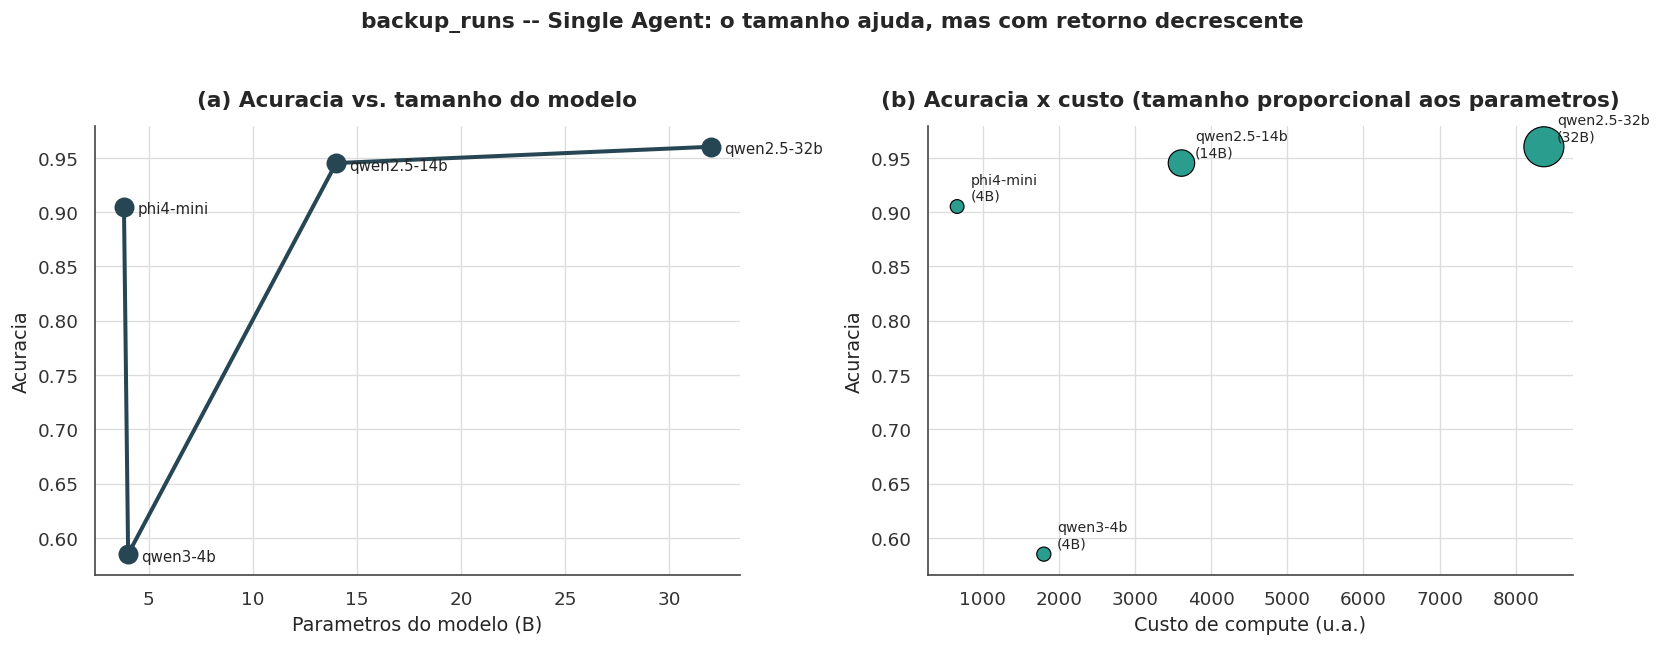

In [20]:
sa = sum_bak[sum_bak.protocol=="single_agent"].copy()
sa = sa.sort_values("minion_params_b")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
axes[0].plot(sa["minion_params_b"], sa["accuracy"], "-o", markersize=11,
             linewidth=2.4, color="#264653")
for _, r in sa.iterrows():
    axes[0].annotate(r["minion"], (r["minion_params_b"], r["accuracy"]),
                     textcoords="offset points", xytext=(8, -4), fontsize=9)
axes[0].set_xlabel("Parametros do modelo (B)"); axes[0].set_ylabel("Acuracia")
axes[0].set_title("(a) Acuracia vs. tamanho do modelo")

axes[1].scatter(sa["avg_compute_cost"], sa["accuracy"],
                s=sa["minion_params_b"]*18, color="#2A9D8F",
                edgecolor="black", linewidth=0.7)
for _, r in sa.iterrows():
    axes[1].annotate(f"{r['minion']}\n({r['minion_params_b']:.0f}B)",
                     (r["avg_compute_cost"], r["accuracy"]),
                     textcoords="offset points", xytext=(8, 4), fontsize=8.5)
axes[1].set_xlabel("Custo de compute (u.a.)"); axes[1].set_ylabel("Acuracia")
axes[1].set_title("(b) Acuracia x custo (tamanho proporcional aos parametros)")
for ax in axes: style_ax(ax)
fig.suptitle("backup_runs -- Single Agent: o tamanho ajuda, mas com retorno decrescente",
             fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig(FIG_DIR / "backup_single_agent_escala.png")
plt.show()


> Note a **inversão qwen3-4b vs phi4-mini**: apesar de maior (4B vs 3.8B),
> o `qwen3-4b` tem a *pior* acurácia (58,5%), enquanto modelos da família
> `qwen2.5` escalam bem até 96% em 32B. Parâmetros não contam toda a história —
> o treinamento importa.

### 7.3 Debate — efeito do número de agentes e rodadas

O protocolo de **Debate** só aparece nos `backup_runs`. Cada agente argumenta e vota; mais agentes podem melhorar a robustez.

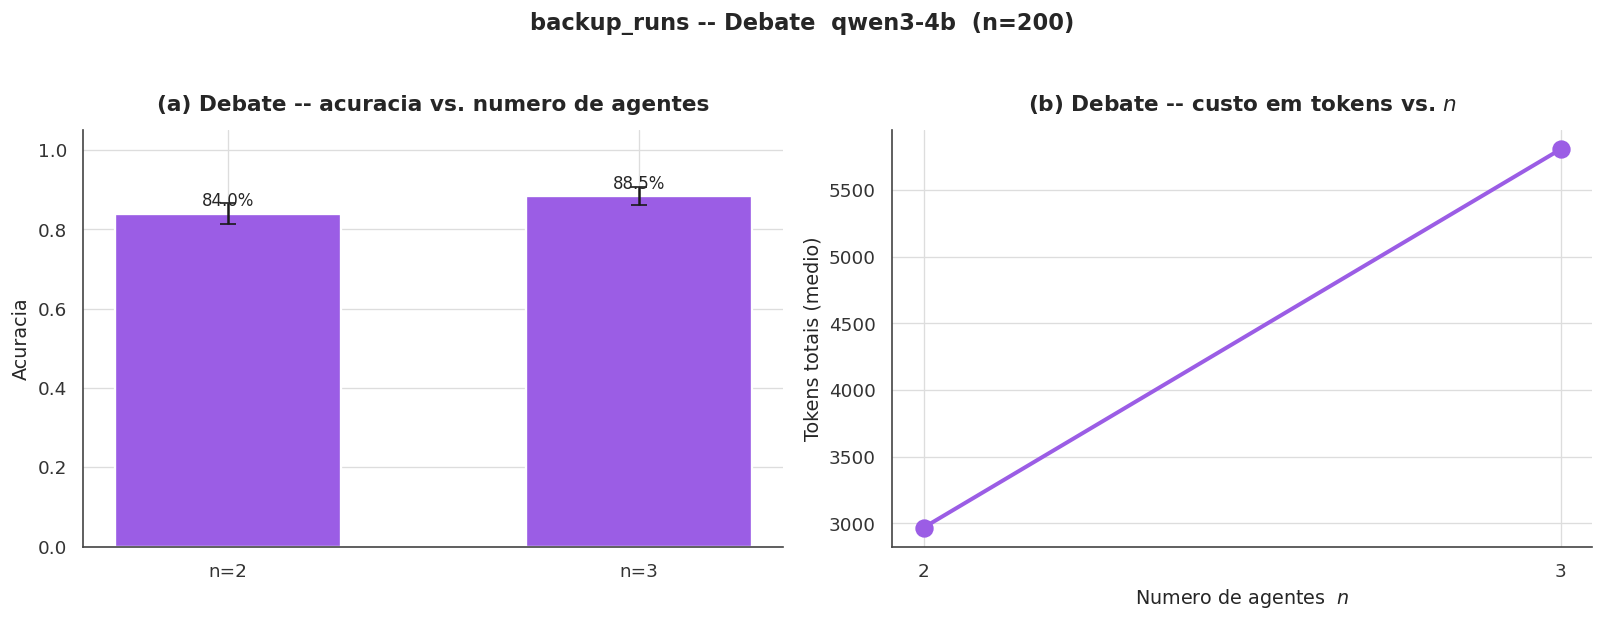

In [21]:
deb = sum_bak[sum_bak.protocol=="debate"].sort_values("n_minions")

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5))
acc, nn = deb["accuracy"].values, deb["n"].values
err = np.sqrt(acc*(1-acc)/nn)
b = axes[0].bar([f"n={n}" for n in deb["n_minions"]], acc, yerr=err, capsize=5,
                color=PROTOCOL_COLORS["debate"], edgecolor="white", linewidth=1.4, width=0.55)
bar_labels(axes[0], b, "{:.1%}", fontsize=10)
axes[0].set_ylim(0, 1.05); axes[0].set_ylabel("Acuracia")
axes[0].set_title("(a) Debate -- acuracia vs. numero de agentes")

axes[1].plot(deb["n_minions"], deb["avg_total_tokens"], "-o", markersize=10,
             linewidth=2.4, color=PROTOCOL_COLORS["debate"], label="Tokens")
axes[1].set_xticks(deb["n_minions"]); axes[1].set_xlabel("Numero de agentes  $n$")
axes[1].set_ylabel("Tokens totais (medio)")
axes[1].set_title("(b) Debate -- custo em tokens vs. $n$")
for ax in axes: style_ax(ax)
fig.suptitle("backup_runs -- Debate  qwen3-4b  (n=200)",
             fontsize=13.5, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig(FIG_DIR / "backup_debate.png")
plt.show()


### 7.4 Dispersão de votos no Debate

`vote_distribution` registra como os agentes votaram em cada pergunta. Medimos a
**concordância** (fração de votos na opção majoritária) e a relacionamos ao acerto.

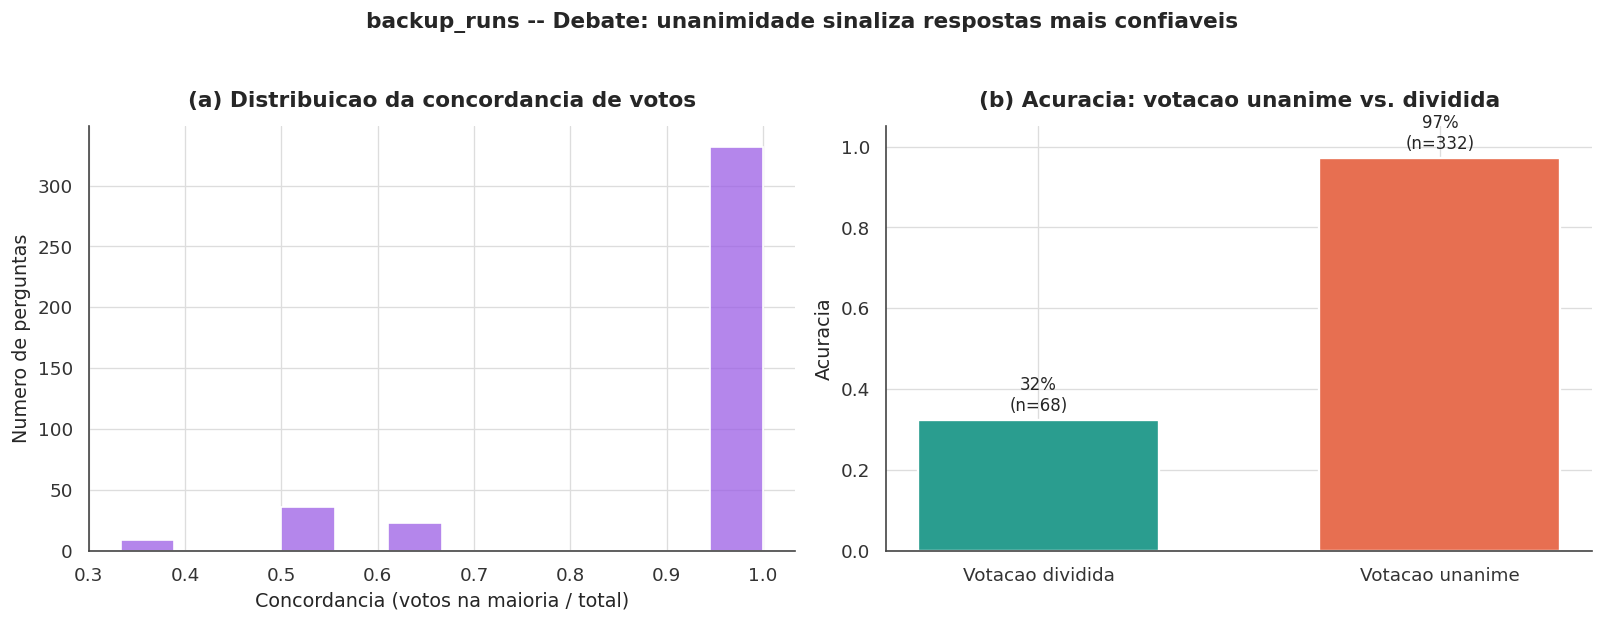

In [22]:
dv = raw_bak[(raw_bak.protocol=="debate")].dropna(subset=["vote_distribution"]).copy()
def agreement(vd):
    if not isinstance(vd, dict) or not vd: return np.nan
    counts = list(vd.values()); return max(counts)/sum(counts)
dv["agreement"] = dv["vote_distribution"].apply(agreement)
dv["unanime"] = dv["agreement"] >= 0.999

g = dv.groupby("unanime")["correct"].agg(["mean","size"]).reset_index()
g["label"] = g["unanime"].map({True:"Votacao unanime", False:"Votacao dividida"})

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5))
sns.histplot(dv["agreement"], bins=12, ax=axes[0], color=PROTOCOL_COLORS["debate"],
             edgecolor="white")
axes[0].set_xlabel("Concordancia (votos na maioria / total)")
axes[0].set_ylabel("Numero de perguntas")
axes[0].set_title("(a) Distribuicao da concordancia de votos")

bars = axes[1].bar(g["label"], g["mean"], color=["#2A9D8F","#E76F51"],
                   edgecolor="white", linewidth=1.4, width=0.6)
for bar, (_, r) in zip(bars, g.iterrows()):
    axes[1].annotate(f"{r['mean']:.0%}\n(n={int(r['size'])})",
                     (bar.get_x()+bar.get_width()/2, bar.get_height()),
                     ha="center", va="bottom", fontsize=10, xytext=(0,3),
                     textcoords="offset points")
axes[1].set_ylim(0, 1.05); axes[1].set_ylabel("Acuracia")
axes[1].set_title("(b) Acuracia: votacao unanime vs. dividida")
for ax in axes: style_ax(ax)
fig.suptitle("backup_runs -- Debate: unanimidade sinaliza respostas mais confiaveis",
             fontsize=13, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig(FIG_DIR / "backup_debate_votos.png")
plt.show()


### 7.5 Minions com master grande — o tamanho do master importa?

No protocolo Minions, o minion responde e o master só intervém em casos difíceis. Comparamos o mesmo minion com masters de 14B e 32B.

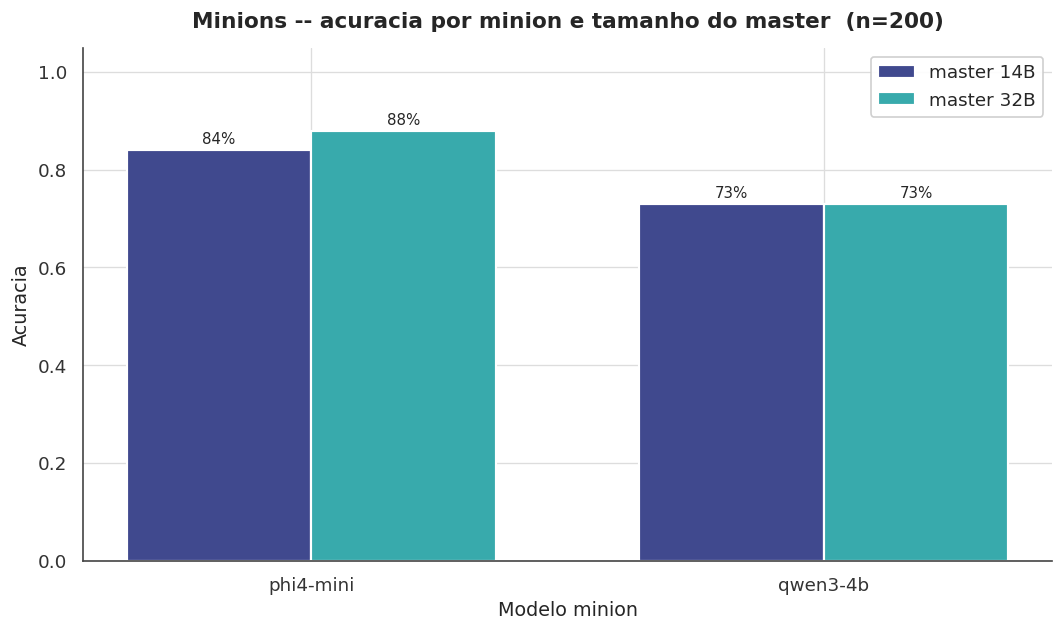

In [23]:
mn = sum_bak[sum_bak.protocol=="minions"].copy()
mn = mn.sort_values(["minion","master_params_b"])

fig, ax = plt.subplots(figsize=(9, 5.4))
minions_u = sorted(mn.minion.unique())
width = 0.36
x = np.arange(len(minions_u))
for i, mp in enumerate(sorted(mn.master_params_b.unique())):
    vals = [mn[(mn.minion==m) & (mn.master_params_b==mp)]["accuracy"].mean() for m in minions_u]
    b = ax.bar(x + (i-0.5)*width, vals, width,
               label=f"master {int(mp)}B",
               color=sns.color_palette("mako", 2)[i], edgecolor="white", linewidth=1.3)
    bar_labels(ax, b, "{:.0%}", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(minions_u)
ax.set_xlabel("Modelo minion"); ax.set_ylabel("Acuracia"); ax.set_ylim(0, 1.05)
ax.set_title("Minions -- acuracia por minion e tamanho do master  (n=200)")
ax.legend()
style_ax(ax)
plt.tight_layout()
plt.savefig(FIG_DIR / "backup_minions_master.png")
plt.show()


> Para o protocolo Minions, **dobrar o master de 14B para 32B não muda a
> acurácia** — o desempenho é ditado pelo minion. Outra evidência de que gastar
> compute no orquestrador, sem melhorar quem de fato resolve, traz pouco retorno.

### 7.6 Panorama final — todos os protocolos em n=200

Fronteira acurácia × custo unificando *todos* os `backup_runs`, para fechar a comparação com amostra grande e confiável.

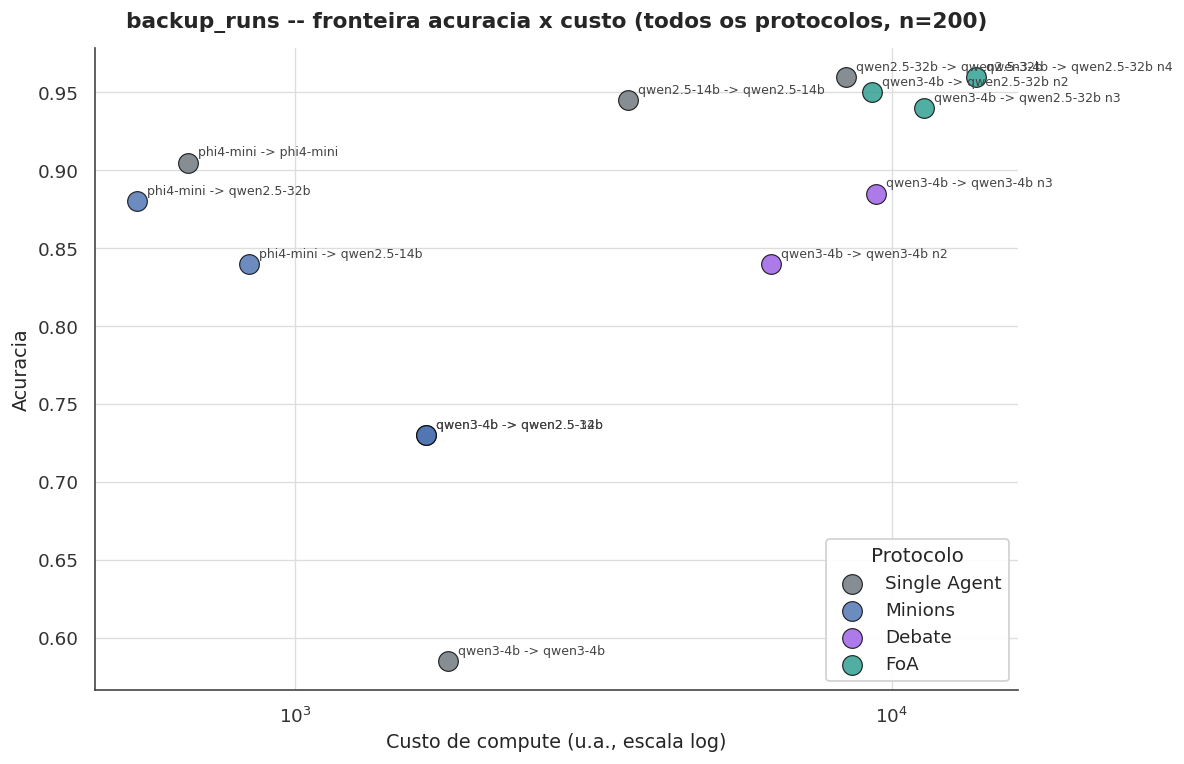

In [24]:
allb = sum_bak.copy()
fig, ax = plt.subplots(figsize=(10, 6.5))
for proto in ["single_agent","minions","debate","mixture_of_agents","foa","foa_dag"]:
    sub = allb[allb.protocol==proto]
    if sub.empty:
        continue
    ax.scatter(sub["avg_compute_cost"], sub["accuracy"],
               s=140, color=PROTOCOL_COLORS[proto], alpha=0.82,
               edgecolor="black", linewidth=0.7, label=PROTOCOL_LABELS[proto])
    for _, r in sub.iterrows():
        tag = r["config"] + (f" n{r['n_minions']}" if r["n_minions"]>1 else "")
        ax.annotate(tag, (r["avg_compute_cost"], r["accuracy"]),
                    textcoords="offset points", xytext=(6, 4), fontsize=7.5,
                    color="#444444")
ax.set_xscale("log")
ax.set_xlabel("Custo de compute (u.a., escala log)")
ax.set_ylabel("Acuracia")
ax.set_title("backup_runs -- fronteira acuracia x custo (todos os protocolos, n=200)")
ax.legend(title="Protocolo", loc="lower right")
style_ax(ax)
plt.tight_layout()
plt.savefig(FIG_DIR / "backup_pareto_geral.png")
plt.show()


## 8. Conclusões

**Sobre o número de agentes `n` no FoA**

- A acurácia **satura rapidamente**: na varredura principal (n=30) o ganho de
  `n=2 -> 4` é nulo ou negativo; em n=200 com master forte, fica essencialmente
  estável (~95%) enquanto o **custo cresce de forma quase linear** com `n`.
- A **eficiência** (acurácia por token e por segundo) **cai** com `n` — `n=2`
  costuma ser o ponto de melhor relação custo-benefício.
- Mais agentes **dificultam o consenso**, forçando rodadas extras e elevando o
  custo; perguntas resolvidas por consenso têm acurácia maior.

**Comparação entre protocolos**

- O **master forte** importa mais que a quantidade de agentes: trocar o
  agregador fraco pelo forte recupera acurácia sem inflar tanto o custo.
- **FoA-DAG** não superou o FoA plano neste benchmark.
- No **Debate**, mais agentes ajudam um pouco, e a **unanimidade dos votos**
  é um bom indicador de confiança na resposta.
- Em **Minions**, o tamanho do master é quase irrelevante — quem resolve é o minion.
- Tamanho do modelo ajuda, mas com **retorno decrescente** e dependente da
  família (qwen2.5 escala bem; qwen3-4b decepciona apesar do tamanho).

Todas as figuras foram exportadas para `results/figures_analysis/`.